# **Trabajo práctico computacional: modelo de Ising en dos dimensiones**

*El TP de Ising, pero en la forma de las ojeras de los alumnos que entregan el trabajo a medianoche y piensan que imitar la manera en que el JTP nombra las clases prácticas es gracioso, aunque nadie termina de saber si esperan hacer reír al JTP o simplemente sobrevivir a la entrega.*

---

### **Integrantes**
- Apolo Bautista
- Fuentes Milagros
- Gay Merino Florencia
- Rodriguez Camps Maximiliano
- Saenz Agustín




##Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from scipy.optimize import curve_fit
from tqdm import tqdm
import pandas as pd
from google.colab import files


##Funciones de ajuste

In [ ]:

def cuadratica(x, a, b, c):
  y = a*x**2 + b*x + c
  return y

In [ ]:
def lineal(x, a, b):
  y = a*x + b
  return y

#Red cuadrada

##Hamiltoniano
La primera tarea es crear la función $h(s)$ que se sigue de $$H(S)=-\sum_{i,j=1}^L S_{ij}(S_{i-1 j}+S_{ij-1}),$$

In [ ]:
@njit
def h(S):
    L = S.shape[0] #el largo lo tomo como la cantidad de filas
    energia = 0
    for i in range(L):
        for j in range(L):
            s = S[i, j]
            arriba    = S[(i-1) % L, j]  #con esto me aseguro que siempre me devuelva un valor entre 0 y L-1 . Esto es el analogo a S_i-1,j
            izquierda = S[i, (j-1) % L]
            energia += s * (arriba + izquierda)
    return -energia

##Funciones Metropolis

Acá es importante definir la diferencia de energía al dar vuelta el espín que es:
 $\Delta E = 2 s_{ij} \sum_{\text{vecinos}} s$
 y también la diferencia de magnetización $\Delta M = -2\, s_{ij}$.

In [ ]:
@njit
def metropolis1(S, prob4, prob8):
    L = S.shape[0]
    r = np.random.randint(L*L) # numero random entre 0 y L*L
    i, j = divmod(r, L) # un sitio random en la matriz

    valor = S[i, j]

# vecinos utilizando las condiciones de borde como hicimos antes
    arriba    = S[(i-1) % L, j]
    abajo     = S[(i+1) % L, j]
    izquierda = S[i, (j-1) % L]
    derecha   = S[i, (j+1) % L]

    N = arriba + abajo + izquierda + derecha # suma de  vecinos
    dE = 2 * valor * N


    if dE <= 0: # si la dif. de energía es negativa, flipea con prob. 1
        S[i, j] = -valor
        return -2*valor, -2*valor*N  # dm, de

    # dE > 0
    r = np.random.rand()
    if dE == 4:
        if r < prob4:
            S[i, j] = -valor
            return -2*valor, 4
        else:
            return 0, 0

    else:  # dE == 8
        if r < prob8:
            S[i, j] = -valor
            return -2*valor, 8
        else:
            return 0, 0


In [ ]:
@njit
def metropolisTermo(S, prob4, prob8, nequilibrio):
    L = S.shape[0]
    for paso in range(nequilibrio):
        if paso % 200000 == 0:
            print('hello people')
        for __ in range(L*L):
          r = np.random.randint(L2)
          i, j = divmod(r, L)

          valor = S[i, j]

          arriba    = S[(i - 1) % L, j]
          abajo     = S[(i + 1) % L, j]
          izquierda = S[i, (j - 1) % L]
          derecha   = S[i, (j + 1) % L]

          N = arriba + abajo + izquierda + derecha

          dE = 2 * valor * N

          if dE <= 0:
              S[i, j] = -valor

          else:
              r2 = np.random.random()
              if dE == 4:
                    if r2 < prob4:
                        S[i, j] = -valor

              else:
                    if r2 < prob8:
                        S[i, j] = -valor

    return S


In [ ]:
@njit
def metropolisN(S, prob4,prob8, npromedio):
    L = S.shape[0]
    L2 = L * L

    m = np.zeros(npromedio)
    e = np.zeros(npromedio)

    # valores iniciales
    m[0] = np.sum(S)
    e[0] = h(S)

    # loop Montecarlo =====
    for n in range(1, npromedio):

        dM_tot = 0.0
        dE_tot = 0.0

        # Metropolis
        for p in range(L2):

            r = np.random.randint(L2)
            i, j = divmod(r, L)

            valor = S[i, j]

            arriba    = S[(i - 1) % L, j]
            abajo     = S[(i + 1) % L, j]
            izquierda = S[i, (j - 1) % L]
            derecha   = S[i, (j + 1) % L]

            N = arriba + abajo + izquierda + derecha

            dE = 2 * valor * N
            dE_ef = 0.0
            dM = 0.0

            # regla de aceptación
            if dE <= 0:
                S[i, j] = -valor
                dM = -2 * valor
                dE_ef = dE
            else:
                r2 = np.random.random()
                # solo existen dE == 4 o dE == 8 positivos en la red de Ising cuadrada
                if dE == 4:
                    if r2 < prob4:
                        S[i, j] = -valor
                        dM = -2.0 * valor
                        dE_ef = dE
                else:  # dE == 8
                    if r2 < prob8:
                        S[i, j] = -valor
                        dM = -2.0 * valor
                        dE_ef = dE

            dM_tot += dM
            dE_tot += dE_ef

        # actualización de series temporales
        m[n] = m[n - 1] + dM_tot
        e[n] = e[n - 1] + dE_tot

    return np.mean(np.abs(m)), np.mean(e), np.var(np.abs(m)), np.var(e)


##Termalización

In [ ]:
@njit
def metropolis_series(S, prob4, prob8, npasos):
    """
    Igual que metropolisN en espíritu, pero devuelve:
    - S final
    - serie de magnetización total m[n]
    - serie de energía total e[n]
    para hacer los gráficos de termalización.
    """
    L = S.shape[0]
    L2 = L * L

    m = np.zeros(npasos)
    e = np.zeros(npasos)

    # valores iniciales
    m[0] = np.sum(S)
    e[0] = h(S)

    for n in range(1, npasos):

        dM_tot = 0.0
        dE_tot = 0.0

        for p in range(L2):

            r = np.random.randint(L2)
            i, j = divmod(r, L)

            valor = S[i, j]

            arriba    = S[(i - 1) % L, j]
            abajo     = S[(i + 1) % L, j]
            izquierda = S[i, (j - 1) % L]
            derecha   = S[i, (j + 1) % L]

            N = arriba + abajo + izquierda + derecha

            dE = 2.0 * valor * N
            dE_ef = 0.0
            dM = 0.0

            if dE <= 0.0:
                S[i, j] = -valor
                dM = -2.0 * valor
                dE_ef = dE
            else:
                r2 = np.random.random()
                if dE == 4.0:
                    if r2 < prob4:
                        S[i, j] = -valor
                        dM = -2.0 * valor
                        dE_ef = dE
                else:  # dE == 8.0
                    if r2 < prob8:
                        S[i, j] = -valor
                        dM = -2.0 * valor
                        dE_ef = dE

            dM_tot += dM
            dE_tot += dE_ef

        m[n] = m[n - 1] + dM_tot
        e[n] = e[n - 1] + dE_tot

    return S, m, e


hello people


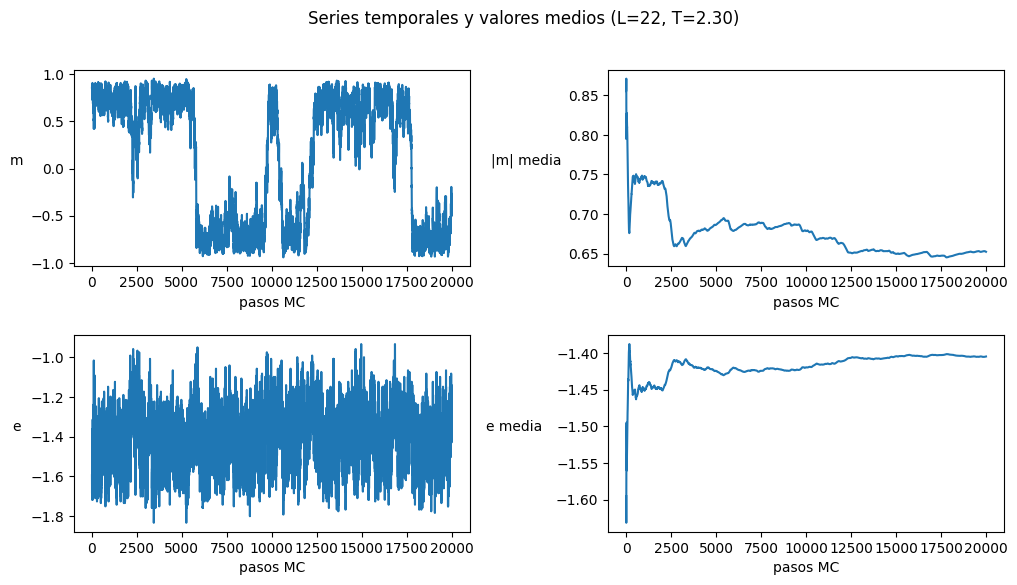

In [ ]:
L = 22
L2 = L * L

T = 2.3
beta = 1.0 / T
prob4 = np.exp(-4.0 * beta)
prob8 = np.exp(-8.0 * beta)

nequilibrio = 10000
npasos      = 20000

# estado inicial
S = np.ones((L, L), dtype=np.int32)

# 1) termalizar
S = metropolisTermo(S, prob4, prob8, nequilibrio)

# 2) generar series
S_fin, m_tot, e_tot = metropolis_series(S, prob4, prob8, npasos)

# 3) pasar a "por espín"
m = m_tot / L2
e = e_tot / L2

# 4) calcular |m| media y e media acumuladas
mmedia = np.zeros(npasos)
emedia = np.zeros(npasos)

mmedia[0] = abs(m[0])
emedia[0] = e[0]

for n in range(1, npasos):
    mmedia[n] = (n * mmedia[n-1] + abs(m[n])) / (n + 1)
    emedia[n] = (n * emedia[n-1] + e[n])      / (n + 1)

# 5) gráfico 2×2 tipo el del profe
fig = plt.figure(figsize=(12, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.35)
fig.suptitle(f'Series temporales y valores medios (L={L}, T={T:.2f})')

plt.subplot(2, 2, 1)
plt.plot(m)
plt.ylabel('m', rotation=0, labelpad=10)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 2)
plt.plot(mmedia)
plt.ylabel('|m| media', rotation=0, labelpad=30)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 3)
plt.plot(e)
plt.ylabel('e', rotation=0, labelpad=10)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 4)
plt.plot(emedia)
plt.ylabel('e media', rotation=0, labelpad=30)
plt.xlabel('pasos MC')

plt.show()

hello people


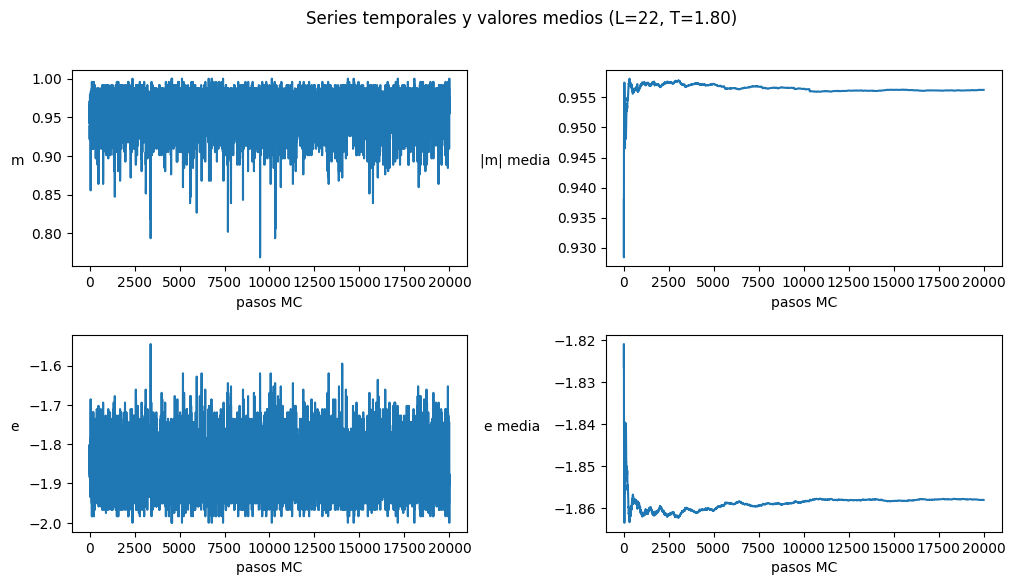

In [ ]:
L = 22
L2 = L * L

T = 1.8 #Una T baja
beta = 1.0 / T
prob4 = np.exp(-4.0 * beta)
prob8 = np.exp(-8.0 * beta)

nequilibrio = 10000
npasos      = 20000

# estado inicial
S = np.ones((L, L), dtype=np.int32)

# 1) termalizar
S = metropolisTermo(S, prob4, prob8, nequilibrio)

# 2) generar series
S_fin, m_tot, e_tot = metropolis_series(S, prob4, prob8, npasos)

# 3) pasar a "por espín"
m = m_tot / L2
e = e_tot / L2

# 4) calcular |m| media y e media acumuladas
mmedia = np.zeros(npasos)
emedia = np.zeros(npasos)

mmedia[0] = abs(m[0])
emedia[0] = e[0]

for n in range(1, npasos):
    mmedia[n] = (n * mmedia[n-1] + abs(m[n])) / (n + 1)
    emedia[n] = (n * emedia[n-1] + e[n])      / (n + 1)

# 5) gráfico 2×2 tipo el del profe
fig = plt.figure(figsize=(12, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.35)
fig.suptitle(f'Series temporales y valores medios (L={L}, T={T:.2f})')

plt.subplot(2, 2, 1)
plt.plot(m)
plt.ylabel('m', rotation=0, labelpad=10)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 2)
plt.plot(mmedia)
plt.ylabel('|m| media', rotation=0, labelpad=30)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 3)
plt.plot(e)
plt.ylabel('e', rotation=0, labelpad=10)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 4)
plt.plot(emedia)
plt.ylabel('e media', rotation=0, labelpad=30)
plt.xlabel('pasos MC')

plt.show()

hello people


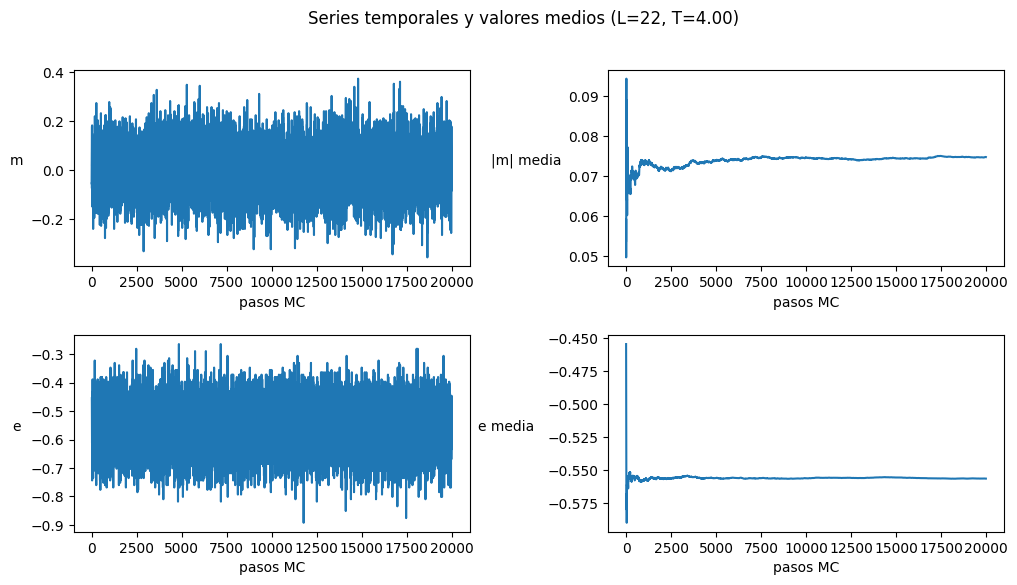

In [ ]:
L = 22
L2 = L * L

T = 4 #Una T alta
beta = 1.0 / T
prob4 = np.exp(-4.0 * beta)
prob8 = np.exp(-8.0 * beta)

nequilibrio = 10000
npasos      = 20000

# estado inicial
S = np.ones((L, L), dtype=np.int32)

# 1) termalizar
S = metropolisTermo(S, prob4, prob8, nequilibrio)

# 2) generar series
S_fin, m_tot, e_tot = metropolis_series(S, prob4, prob8, npasos)

# 3) pasar a "por espín"
m = m_tot / L2
e = e_tot / L2

# 4) calcular |m| media y e media acumuladas
mmedia = np.zeros(npasos)
emedia = np.zeros(npasos)

mmedia[0] = abs(m[0])
emedia[0] = e[0]

for n in range(1, npasos):
    mmedia[n] = (n * mmedia[n-1] + abs(m[n])) / (n + 1)
    emedia[n] = (n * emedia[n-1] + e[n])      / (n + 1)

# 5) gráfico 2×2 tipo el del profe
fig = plt.figure(figsize=(12, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.35)
fig.suptitle(f'Series temporales y valores medios (L={L}, T={T:.2f})')

plt.subplot(2, 2, 1)
plt.plot(m)
plt.ylabel('m', rotation=0, labelpad=10)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 2)
plt.plot(mmedia)
plt.ylabel('|m| media', rotation=0, labelpad=30)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 3)
plt.plot(e)
plt.ylabel('e', rotation=0, labelpad=10)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 4)
plt.plot(emedia)
plt.ylabel('e media', rotation=0, labelpad=30)
plt.xlabel('pasos MC')

plt.show()

Bueno, acá hicimos el análisis para una red cuadrada de L=22 para que no tardara tanto en correr. Analizamos cómo varía, para distintos pasos de Montecarlo, la energía, la magnetización y sus valores medios para tres temperaturas diferentes.
Concluimos, en principio, que las funciones metropolis funcionan bien, ya que para una temperatura cercana a la crítica las oscilaciones de la magnetización son bien marcadas y la curva tarda muchísimo más en “asentarse”. Además, se ve claramente que la energía se estabiliza mucho antes que la magnetización, lo cual coincide con lo que se espera teóricamente.

Utilizamos un criterio más bien cualitativo (a ojo) para elegir el número de pasos de termalización, y en el caso crítico tomamos algo del orden de n≈10000, que es suficiente para que tanto e(n) como m(n) dejen de mostrar una deriva clara.

Para temperaturas bajas se ve cómo el sistema queda rápidamente atrapado en un estado ordenado, con todos los espines apuntando en la misma dirección. La magnetización se mantiene cercana a 1 todo el tiempo y la energía siempre es negativa, como corresponde a una fase ferromagnética. En este régimen la estabilización es mucho más rápida, ya desde
n≈5000(e incluso antes) los valores medios prácticamente no cambian.

Para temperaturas altas (por ejemplo T = 4K), la magnetización fluctúa alrededor de cero y su valor absoluto es muy pequeño, como se espera para una fase completamente desordenada. La red pierde cualquier estructura global y lo único que queda son fluctuaciones térmicas aleatorias. En este caso la termalización también es rápida porque no hay correlaciones de largo alcance: tanto la energía como la magnetización se estacionan en los primeros cientos o miles de pasos.

En resumen, la termalización depende bastante de la temperatura: cerca de la crítica el proceso es lento, a baja T es muy rápido porque el sistema se ordena enseguida, y a alta T también es rápido porque los espines se comportan de manera casi independiente. Estas observaciones coinciden con lo esperado para el modelo de Ising y sirven para justificar la elección del número de pasos de equilibrio que vamos a usar después en la parte de los promedios y la transición de fase.

Por ultimo, vamos analizar una red un poco mas grande.

hello people


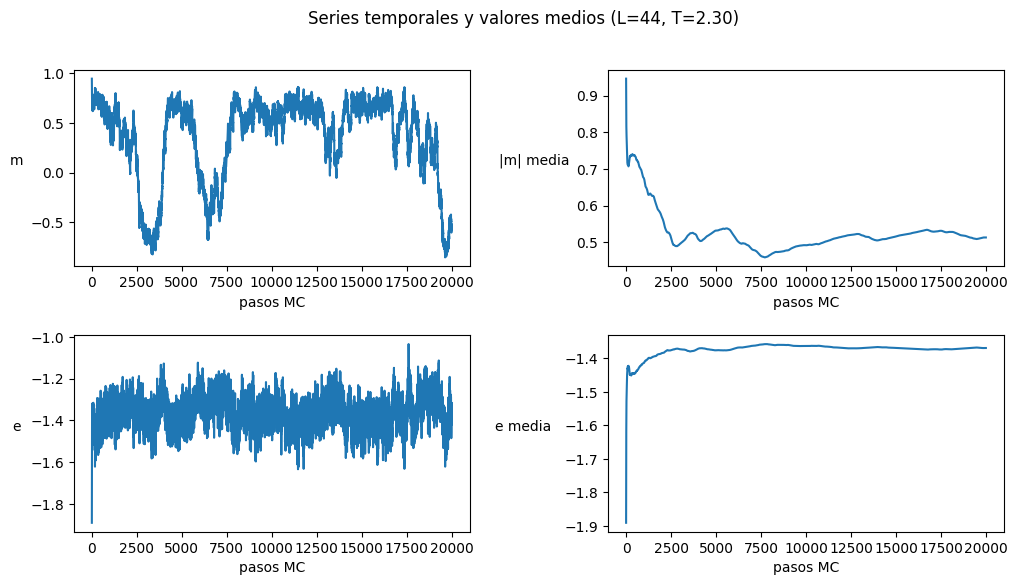

In [ ]:
L = 44
L2 = L * L

T = 2.3 #Una T cercana a T_c
beta = 1.0 / T
prob4 = np.exp(-4.0 * beta)
prob8 = np.exp(-8.0 * beta)

nequilibrio = 10000
npasos      = 20000

# estado inicial
S = np.ones((L, L), dtype=np.int32)

# 1) termalizar
S = metropolisTermo(S, prob4, prob8, nequilibrio)

# 2) generar series
S_fin, m_tot, e_tot = metropolis_series(S, prob4, prob8, npasos)

# 3) pasar a "por espín"
m = m_tot / L2
e = e_tot / L2

# 4) calcular |m| media y e media acumuladas
mmedia = np.zeros(npasos)
emedia = np.zeros(npasos)

mmedia[0] = abs(m[0])
emedia[0] = e[0]

for n in range(1, npasos):
    mmedia[n] = (n * mmedia[n-1] + abs(m[n])) / (n + 1)
    emedia[n] = (n * emedia[n-1] + e[n])      / (n + 1)

# 5) gráfico 2×2 tipo el del profe
fig = plt.figure(figsize=(12, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.35)
fig.suptitle(f'Series temporales y valores medios (L={L}, T={T:.2f})')

plt.subplot(2, 2, 1)
plt.plot(m)
plt.ylabel('m', rotation=0, labelpad=10)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 2)
plt.plot(mmedia)
plt.ylabel('|m| media', rotation=0, labelpad=30)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 3)
plt.plot(e)
plt.ylabel('e', rotation=0, labelpad=10)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 4)
plt.plot(emedia)
plt.ylabel('e media', rotation=0, labelpad=30)
plt.xlabel('pasos MC')

plt.show()

Acá claramente nos damos cuenta que ya con n=10000 pasos no me es suficiente, por lo menos para temperaturas cercanas a la critica.

hello people


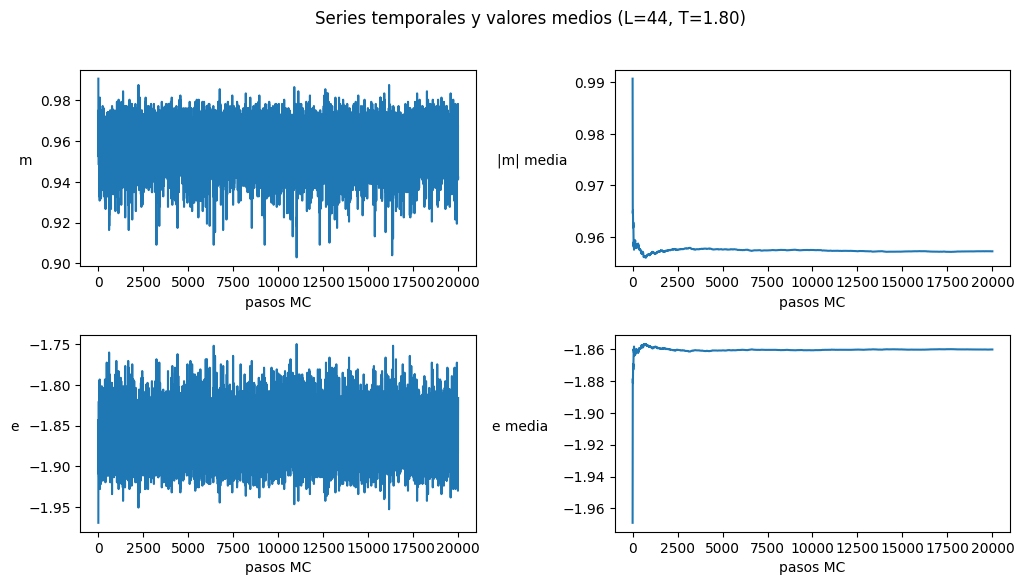

In [ ]:
L = 44
L2 = L * L

T = 1.8 #Una T baja
beta = 1.0 / T
prob4 = np.exp(-4.0 * beta)
prob8 = np.exp(-8.0 * beta)

nequilibrio = 10000
npasos      = 20000

# estado inicial
S = np.ones((L, L), dtype=np.int32)

# 1) termalizar
S = metropolisTermo(S, prob4, prob8, nequilibrio)

# 2) generar series
S_fin, m_tot, e_tot = metropolis_series(S, prob4, prob8, npasos)

# 3) pasar a "por espín"
m = m_tot / L2
e = e_tot / L2

# 4) calcular |m| media y e media acumuladas
mmedia = np.zeros(npasos)
emedia = np.zeros(npasos)

mmedia[0] = abs(m[0])
emedia[0] = e[0]

for n in range(1, npasos):
    mmedia[n] = (n * mmedia[n-1] + abs(m[n])) / (n + 1)
    emedia[n] = (n * emedia[n-1] + e[n])      / (n + 1)

# 5) gráfico 2×2 tipo el del profe
fig = plt.figure(figsize=(12, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.35)
fig.suptitle(f'Series temporales y valores medios (L={L}, T={T:.2f})')

plt.subplot(2, 2, 1)
plt.plot(m)
plt.ylabel('m', rotation=0, labelpad=10)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 2)
plt.plot(mmedia)
plt.ylabel('|m| media', rotation=0, labelpad=30)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 3)
plt.plot(e)
plt.ylabel('e', rotation=0, labelpad=10)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 4)
plt.plot(emedia)
plt.ylabel('e media', rotation=0, labelpad=30)
plt.xlabel('pasos MC')

plt.show()

hello people


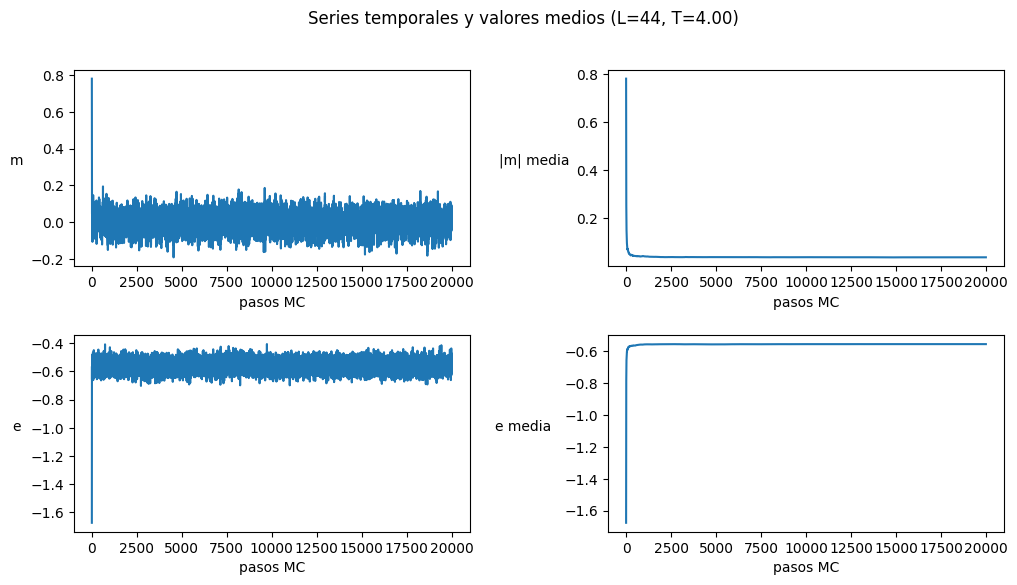

In [ ]:
L = 44
L2 = L * L

T = 4 #Una T alta
beta = 1.0 / T
prob4 = np.exp(-4.0 * beta)
prob8 = np.exp(-8.0 * beta)

nequilibrio = 10000
npasos      = 20000

# estado inicial
S = np.ones((L, L), dtype=np.int32)

# 1) termalizar
S = metropolisTermo(S, prob4, prob8, nequilibrio)

# 2) generar series
S_fin, m_tot, e_tot = metropolis_series(S, prob4, prob8, npasos)

# 3) pasar a "por espín"
m = m_tot / L2
e = e_tot / L2

# 4) calcular |m| media y e media acumuladas
mmedia = np.zeros(npasos)
emedia = np.zeros(npasos)

mmedia[0] = abs(m[0])
emedia[0] = e[0]

for n in range(1, npasos):
    mmedia[n] = (n * mmedia[n-1] + abs(m[n])) / (n + 1)
    emedia[n] = (n * emedia[n-1] + e[n])      / (n + 1)

# 5) gráfico 2×2 tipo el del profe
fig = plt.figure(figsize=(12, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.35)
fig.suptitle(f'Series temporales y valores medios (L={L}, T={T:.2f})')

plt.subplot(2, 2, 1)
plt.plot(m)
plt.ylabel('m', rotation=0, labelpad=10)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 2)
plt.plot(mmedia)
plt.ylabel('|m| media', rotation=0, labelpad=30)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 3)
plt.plot(e)
plt.ylabel('e', rotation=0, labelpad=10)
plt.xlabel('pasos MC')

plt.subplot(2, 2, 4)
plt.plot(emedia)
plt.ylabel('e media', rotation=0, labelpad=30)
plt.xlabel('pasos MC')

plt.show()

Para una red más grande la termalización se vuelve más lenta, especialmente cerca de la temperatura crítica.

En baja temperatura la red sigue ordenándose rápidamente, y en alta temperatura las fluctuaciones siguen siendo rápidas, pero cerca de T_c el *critical slowing down* hace que sea necesario aumentar significativamente el número de pasos de Montecarlo para alcanzar el equilibrio.

**A CONTINUACIÓN VERÁ SEIS SIMULACIONES DE REDES CUADRADAS DE DISTINTO TAMAÑO. TODAS LAS SIMULACIONES FUERON HECHAS EN 300.000 PASOS.**



## Redes

##MAS REDES PARA LA RE-REENTRENGA

###L=10

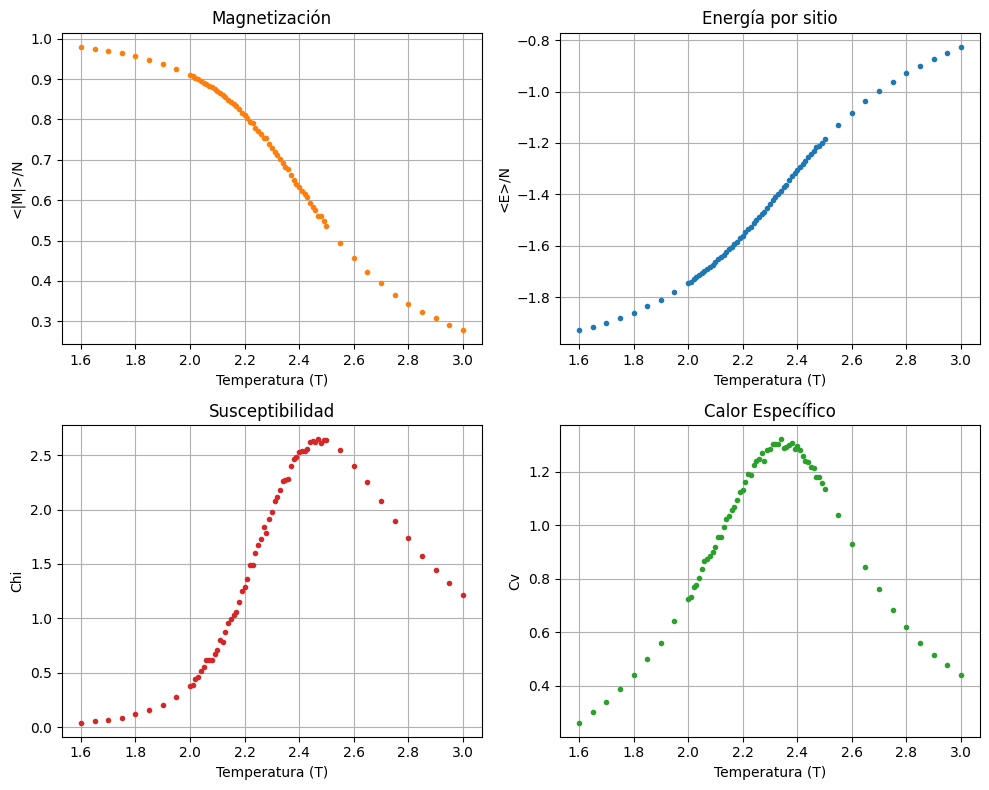

2.3471620850217136


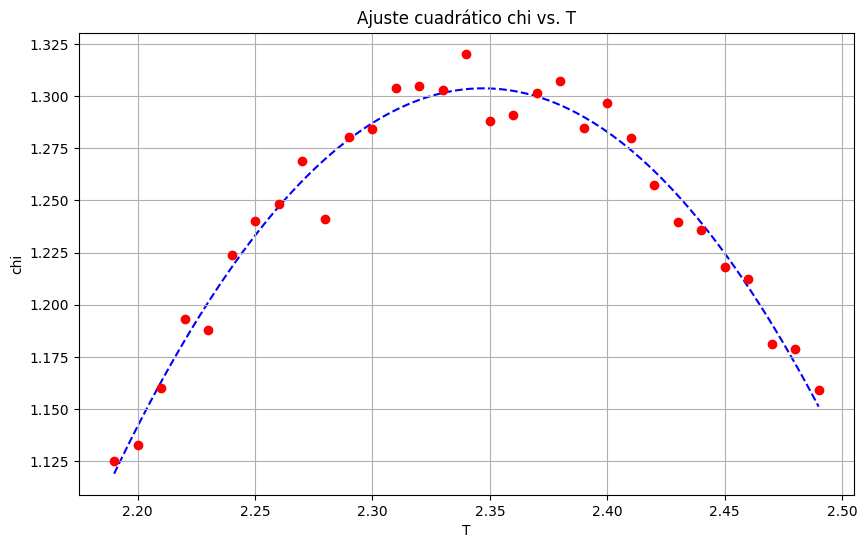

T_max = 2.3471620850217136 +/- 0.0014426721415377738


In [ ]:
# Cuadrada L = 10

df_cuad_10 = pd.read_csv('/content/ising_cuad_L10.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_cuad_10['Temperatura'], df_cuad_10['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_cuad_10['Temperatura'], df_cuad_10['Energia_por_sitio'], '.', color='tab:blue')
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_cuad_10['Temperatura'], df_cuad_10['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_cuad_10['Temperatura'], df_cuad_10['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturasA = np.arange(1.6, 2.0, 0.05)
temperaturascercanas= np.arange(2.0, 2.5, 0.01) # para ver la transición de fase con mayor detalle
temperaturasB = np.arange(2.5, 3.01, 0.05)
temperaturas = np.concatenate((temperaturasA, temperaturascercanas, temperaturasB))

n = 27
m = 58
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_cuad_10['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_cuad_10['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_L10 = T_max
err_Tc_L10 = sigma_Tmax

print("T_max =", Tc_L10, "+/-", err_Tc_L10)

###L=13

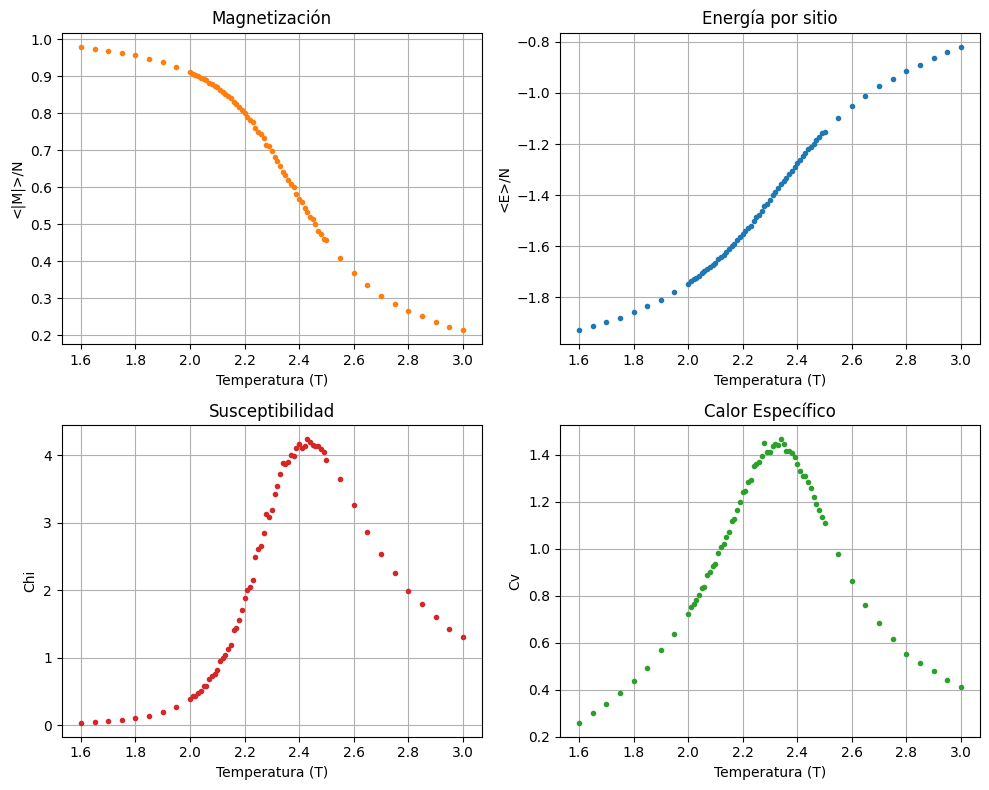

2.3290547112231383


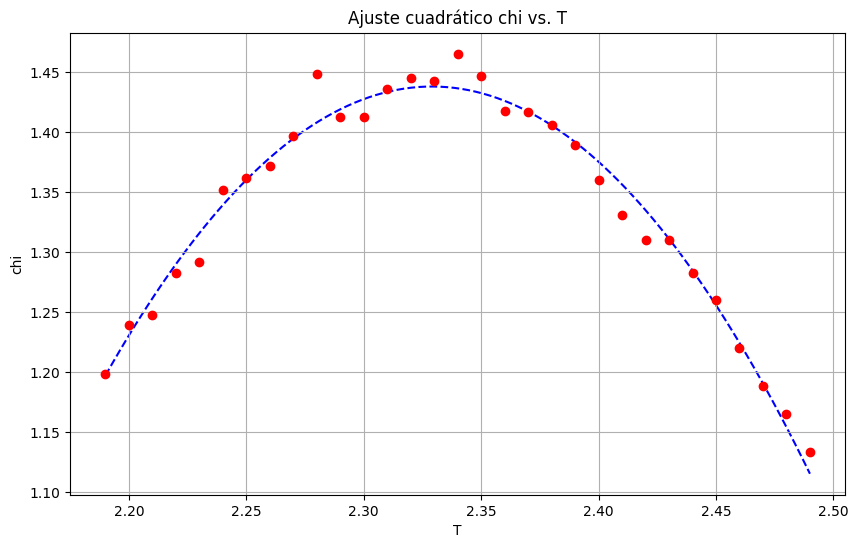

T_max = 2.3290547112231383 +/- 0.001247096612562293


In [ ]:

# Cuadrada L = 13


df_cuad_13 = pd.read_csv('/content/ising_cuad_L13.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_cuad_13['Temperatura'], df_cuad_13['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_cuad_13['Temperatura'], df_cuad_13['Energia_por_sitio'], '.', color='tab:blue')
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_cuad_13['Temperatura'], df_cuad_13['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_cuad_13['Temperatura'], df_cuad_13['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturasA = np.arange(1.6, 2.0, 0.05)
temperaturascercanas= np.arange(2.0, 2.5, 0.01) # para ver la transición de fase con mayor detalle
temperaturasB = np.arange(2.5, 3.01, 0.05)
temperaturas = np.concatenate((temperaturasA, temperaturascercanas, temperaturasB))

n = 27
m = 58
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_cuad_13['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_cuad_13['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_L13 = T_max
err_Tc_L13 = sigma_Tmax

print("T_max =", Tc_L13, "+/-", err_Tc_L13)

###L=20

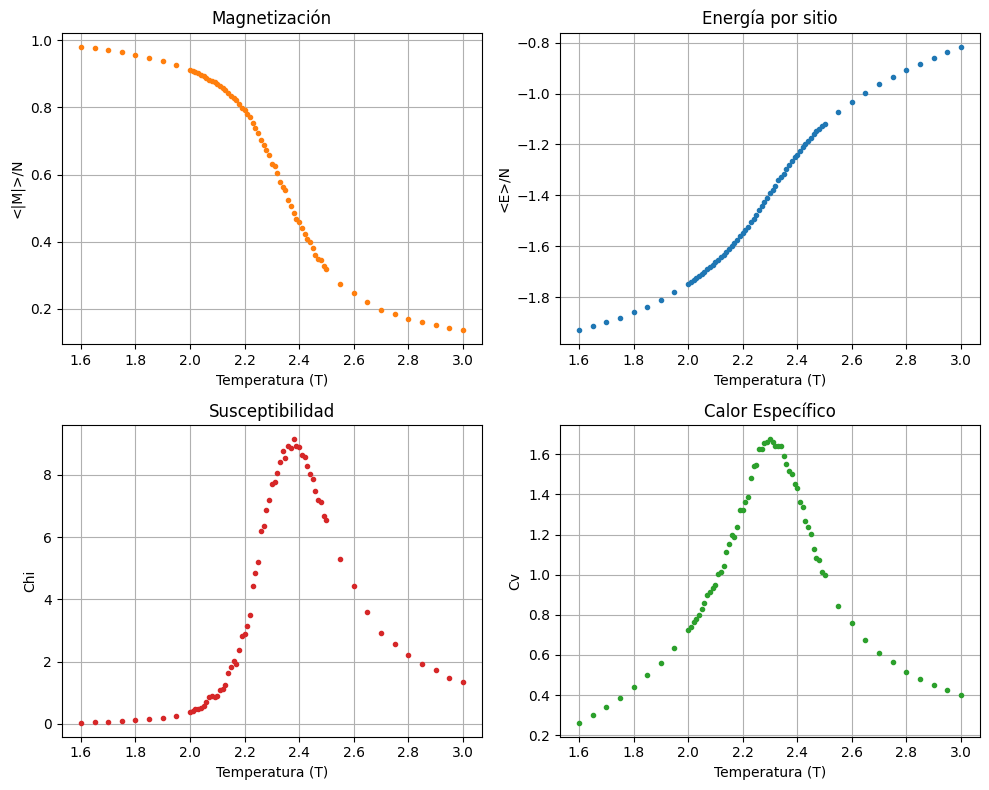

2.3080146989648065


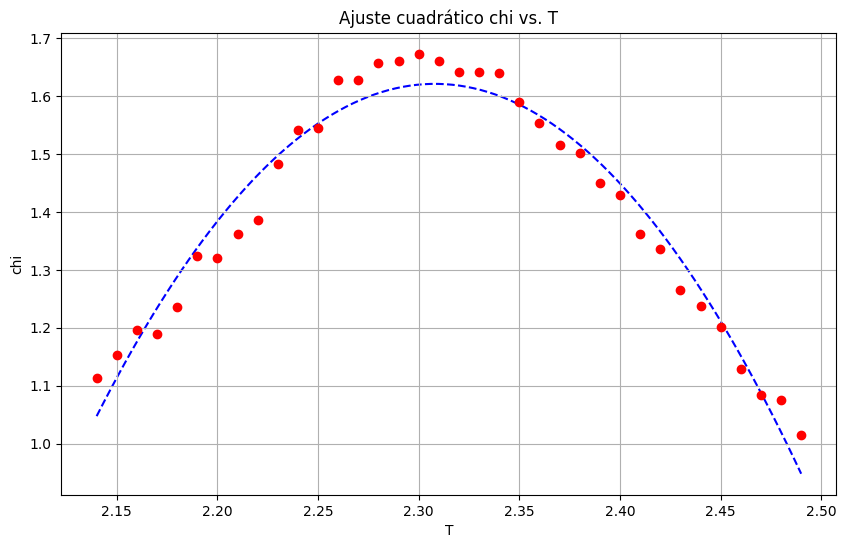

T_max = 2.3080146989648065 +/- 0.0016972495910318266


In [ ]:

# Cuadrada L = 20

df_cuad_20 = pd.read_csv('/content/ising_cuad_L20.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_cuad_20['Temperatura'], df_cuad_20['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_cuad_20['Temperatura'], df_cuad_20['Energia_por_sitio'], '.', color='tab:blue')
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_cuad_20['Temperatura'], df_cuad_20['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_cuad_20['Temperatura'], df_cuad_20['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturasA = np.arange(1.6, 2.0, 0.05)
temperaturascercanas= np.arange(2.0, 2.5, 0.01) # para ver la transición de fase con mayor detalle
temperaturasB = np.arange(2.5, 3.01, 0.05)
temperaturas = np.concatenate((temperaturasA, temperaturascercanas, temperaturasB))

n = 22
m = 58
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_cuad_20['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_cuad_20['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_L20 = T_max
err_Tc_L20 = sigma_Tmax

print("T_max =", Tc_L20, "+/-", err_Tc_L20)

###L= 25

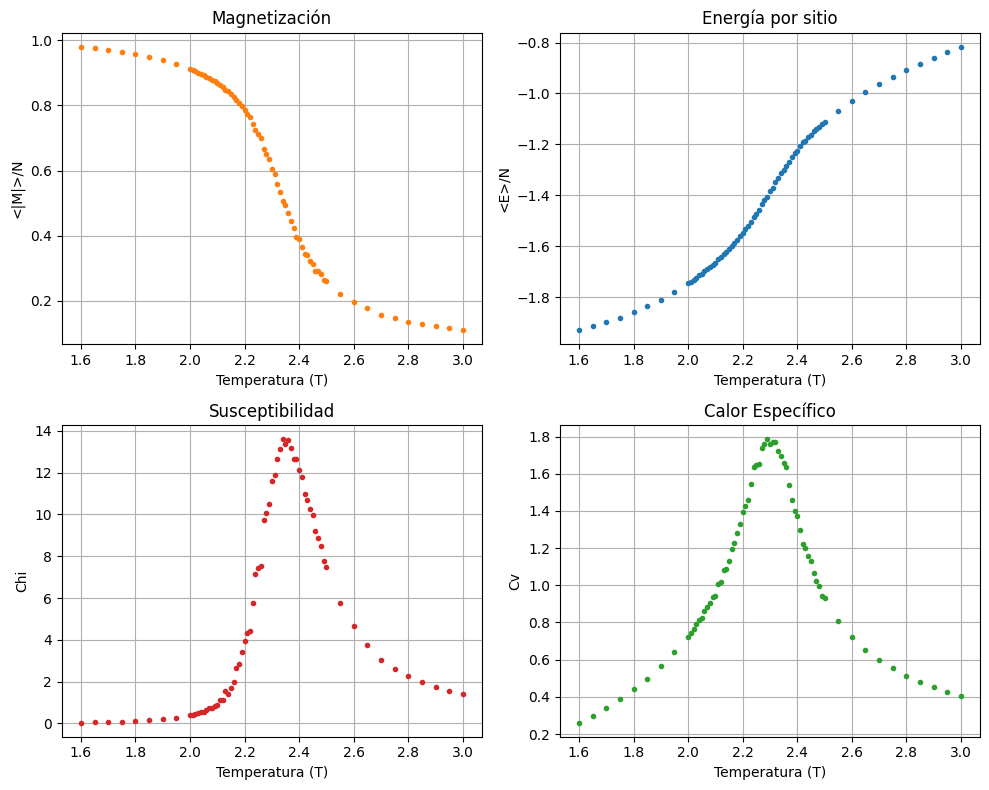

2.2986002253408095


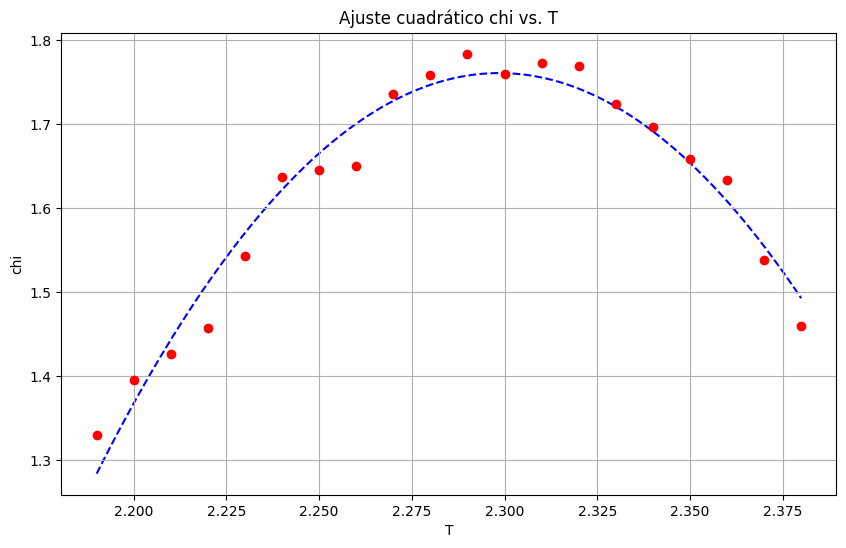

T_max = 2.2986002253408095 +/- 0.0015518817480034007


In [ ]:

# Cuadrada L = 25

df_cuad_25 = pd.read_csv('/content/ising_cuad_L25.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_cuad_25['Temperatura'], df_cuad_25['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_cuad_25['Temperatura'], df_cuad_25['Energia_por_sitio'], '.', color='tab:blue')
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_cuad_25['Temperatura'], df_cuad_25['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_cuad_25['Temperatura'], df_cuad_25['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturasA = np.arange(1.6, 2.0, 0.05)
temperaturascercanas= np.arange(2.0, 2.5, 0.01) # para ver la transición de fase con mayor detalle
temperaturasB = np.arange(2.5, 3.01, 0.05)
temperaturas = np.concatenate((temperaturasA, temperaturascercanas, temperaturasB))

n = 27
m = 47
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_cuad_25['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_cuad_25['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_L25 = T_max
err_Tc_L25 = sigma_Tmax

print("T_max =", Tc_L25, "+/-", err_Tc_L25)

###L= 30


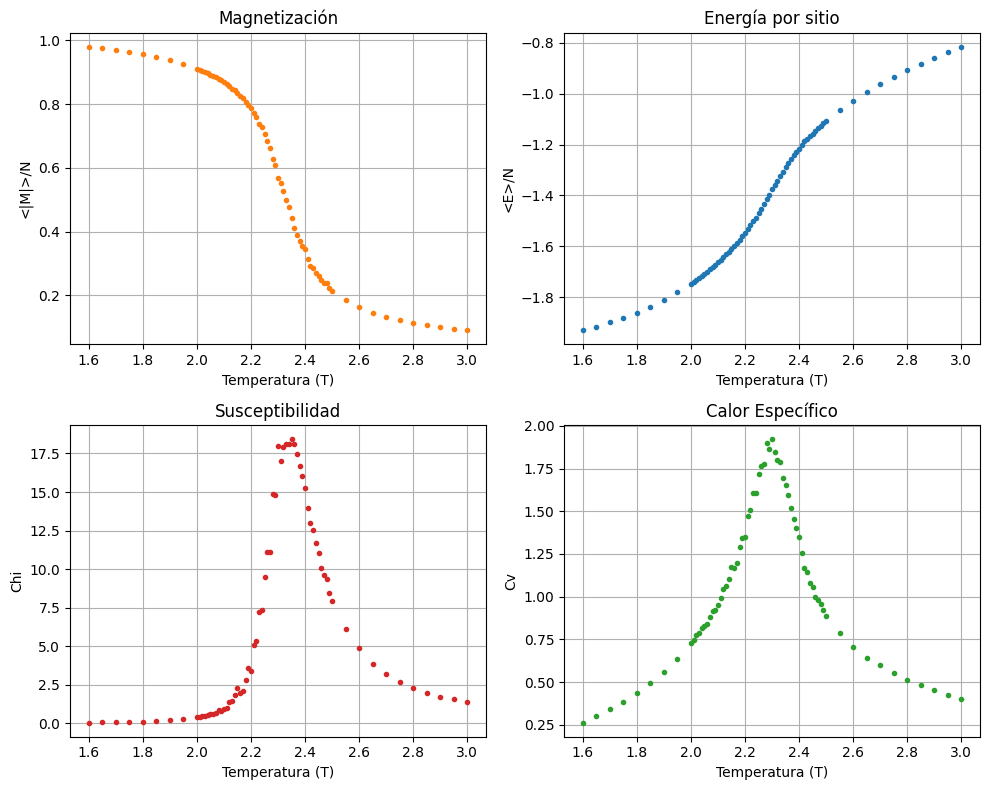

2.2939519862914532


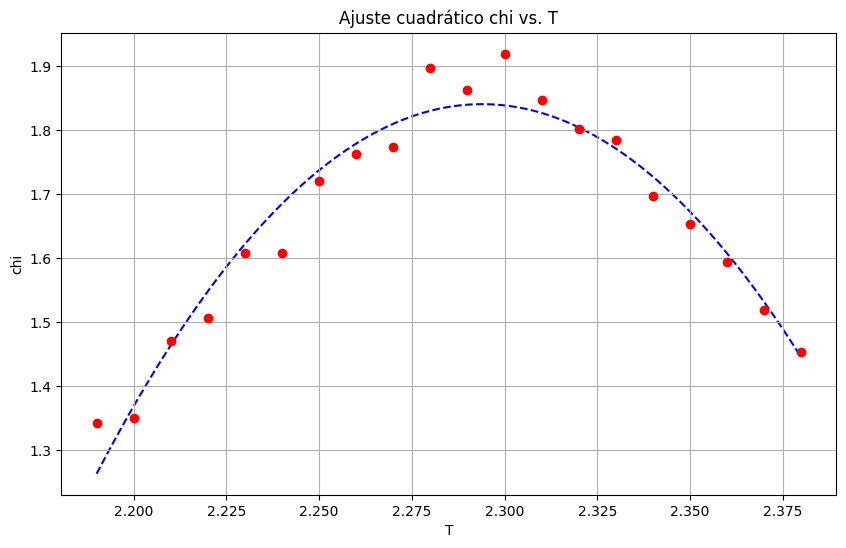

T_max = 2.2939519862914532 +/- 0.00161919756814101


In [ ]:

# Cuadrada L = 30
#El 76 se va cambiando

df_cuad_30 = pd.read_csv('/content/ising_cuad_L30.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_cuad_30['Temperatura'], df_cuad_30['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_cuad_30['Temperatura'], df_cuad_30['Energia_por_sitio'], '.', color='tab:blue')
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_cuad_30['Temperatura'], df_cuad_30['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_cuad_30['Temperatura'], df_cuad_30['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturasA = np.arange(1.6, 2.0, 0.05)
temperaturascercanas= np.arange(2.0, 2.5, 0.01) # para ver la transición de fase con mayor detalle
temperaturasB = np.arange(2.5, 3.01, 0.05)
temperaturas = np.concatenate((temperaturasA, temperaturascercanas, temperaturasB))

n = 27
m = 47
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_cuad_30['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_cuad_30['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_L30 = T_max
err_Tc_L30 = sigma_Tmax

print("T_max =", Tc_L30, "+/-", err_Tc_L30)

### L = 33

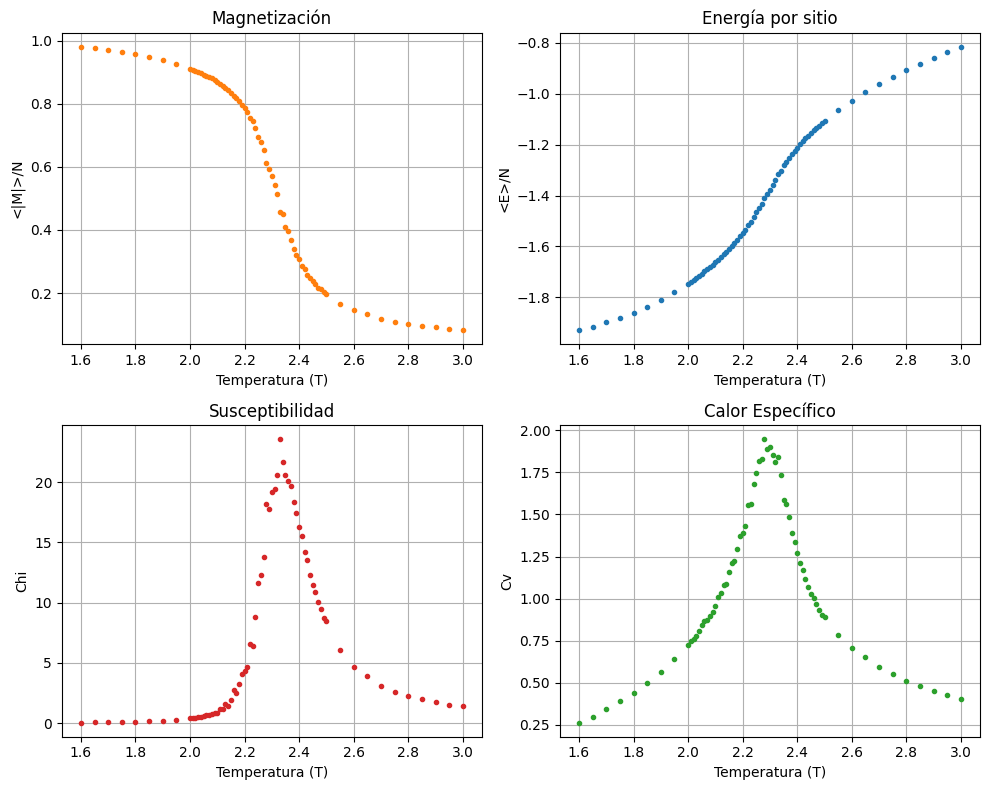

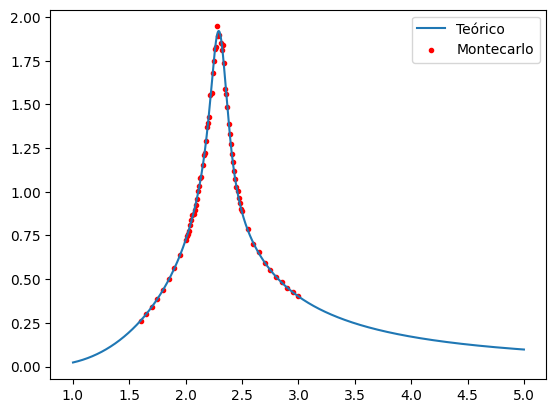

2.2903194959770383


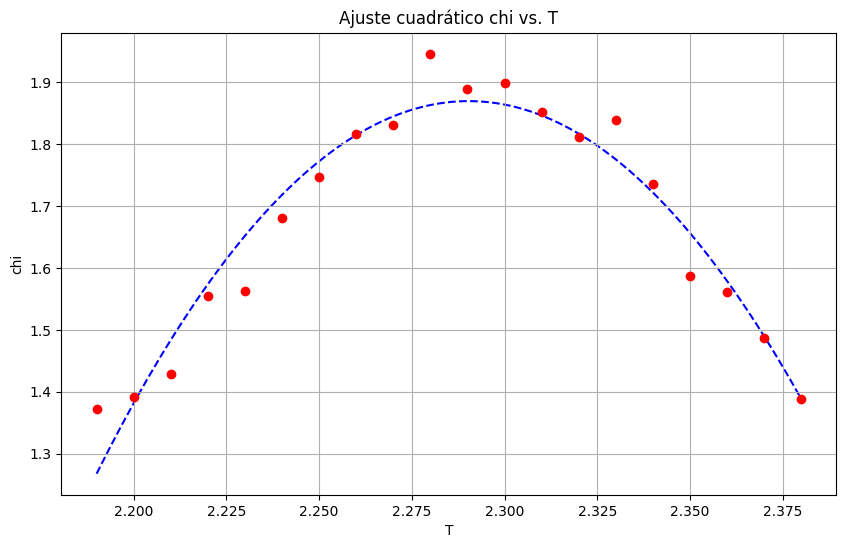

T_max = 2.2903194959770383 +/- 0.0016524409333184538


In [ ]:
# Cuadrada L = 33

df_cuad_33 = pd.read_csv('/content/ising_cuad_L33.csv', delimiter = ';')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_cuad_33['Temperatura'], df_cuad_33['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_cuad_33['Temperatura'], df_cuad_33['Energia_por_sitio'], '.', color='tab:blue')
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_cuad_33['Temperatura'], df_cuad_33['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_cuad_33['Temperatura'], df_cuad_33['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturasA = np.arange(1.6, 2.0, 0.05)
temperaturascercanas= np.arange(2.0, 2.5, 0.01) # para ver la transición de fase con mayor detalle
temperaturasB = np.arange(2.5, 3.01, 0.05)
temperaturas = np.concatenate((temperaturasA, temperaturascercanas, temperaturasB))


df_cuad_teo_33 = pd.read_csv('/content/C_0033.csv')

plt.plot(df_cuad_teo_33.iloc[:, 0], df_cuad_teo_33.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_cuad_33['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 27
m = 47
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_cuad_33['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_cuad_33['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_L33 = T_max
err_Tc_L33 = sigma_Tmax

print("T_max =", Tc_L33, "+/-", err_Tc_L33)

### L = 44

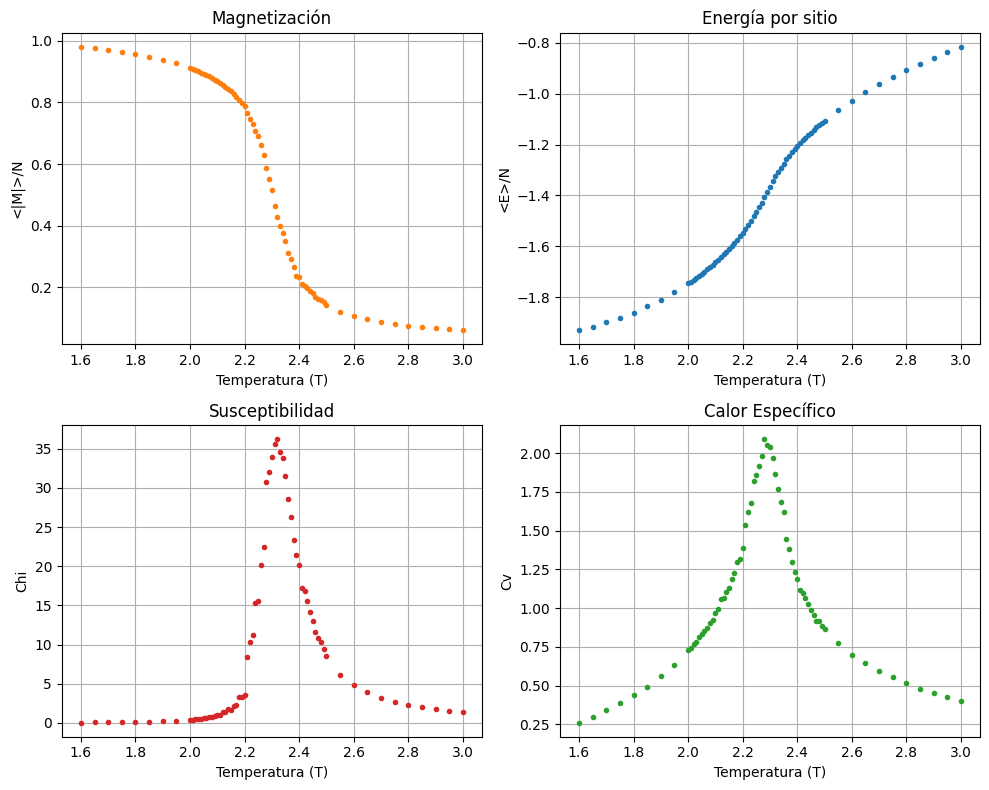

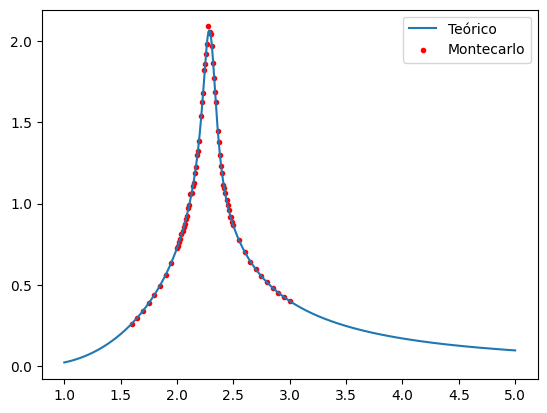

2.2841983608484244


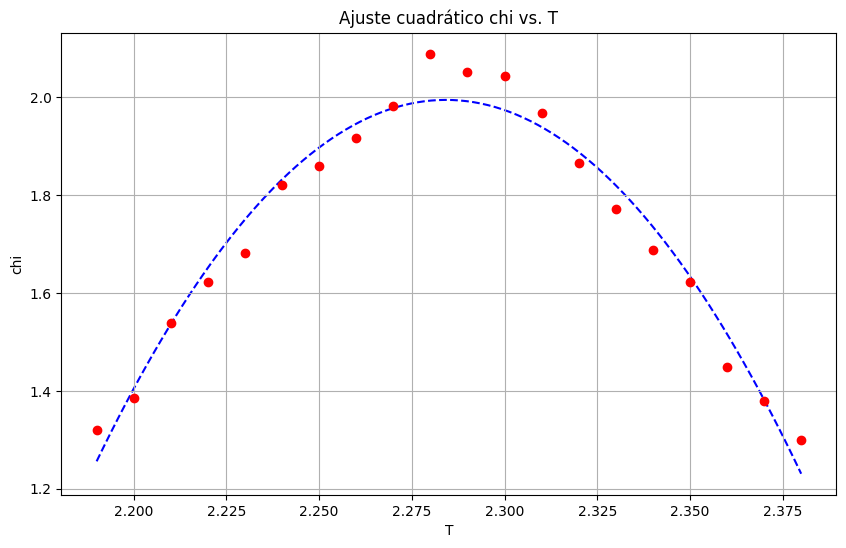

T_max = 2.2841983608484244 +/- 0.0012079840039206195


In [ ]:
# Cuadrada L = 44

df_cuad_44 = pd.read_csv('/content/ising_cuad_L44.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_cuad_44['Temperatura'], df_cuad_44['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_cuad_44['Temperatura'], df_cuad_44['Energia_por_sitio'], '.', color='tab:blue')
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_cuad_44['Temperatura'], df_cuad_44['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_cuad_44['Temperatura'], df_cuad_44['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturasA = np.arange(1.6, 2.0, 0.05)
temperaturascercanas= np.arange(2.0, 2.5, 0.01) # para ver la transición de fase con mayor detalle
temperaturasB = np.arange(2.5, 3.01, 0.05)
temperaturas = np.concatenate((temperaturasA, temperaturascercanas, temperaturasB))


df_cuad_teo_44 = pd.read_csv('/content/C_0044.csv')

plt.plot(df_cuad_teo_44.iloc[:, 0], df_cuad_teo_44.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_cuad_44['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 27
m = 47
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_cuad_44['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_cuad_44['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_L44 = T_max
err_Tc_L44 = sigma_Tmax

print("T_max =", Tc_L44, "+/-", err_Tc_L44)

### L = 50

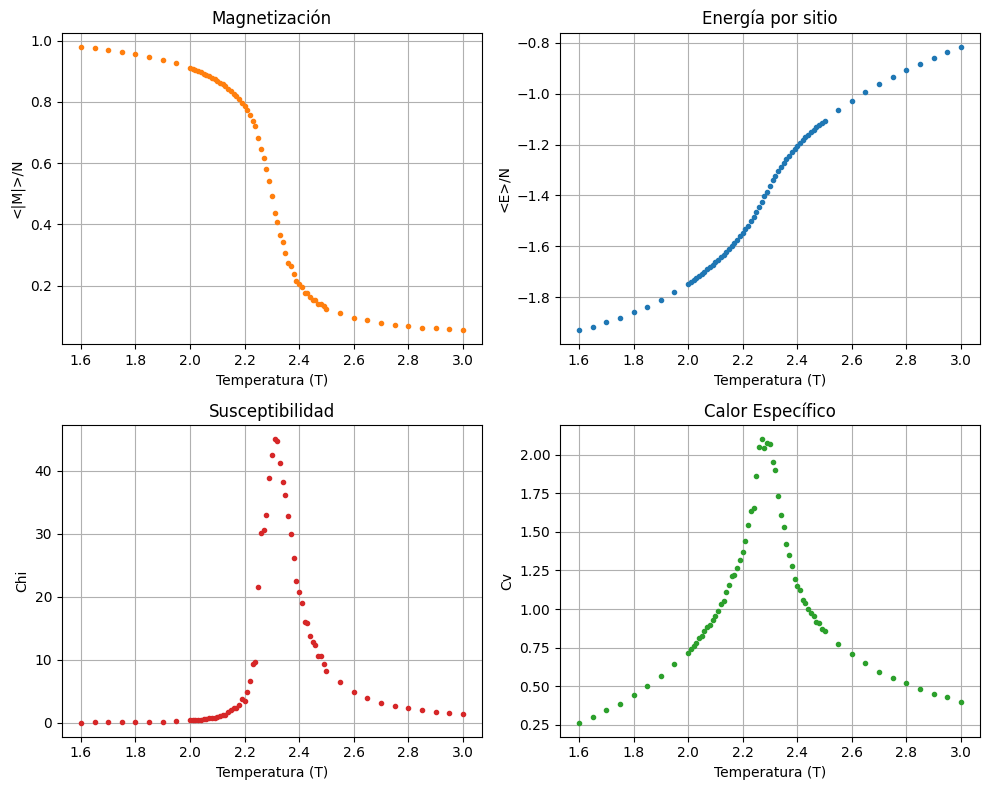

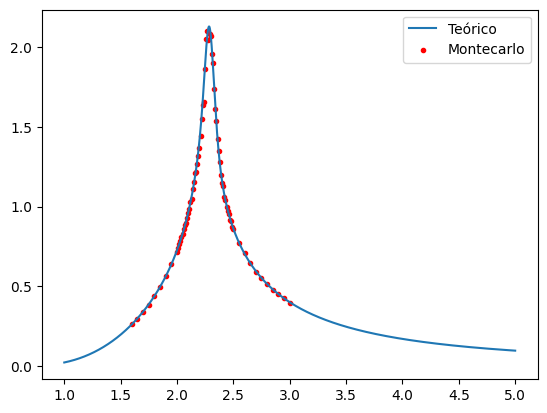

2.2840345264046915


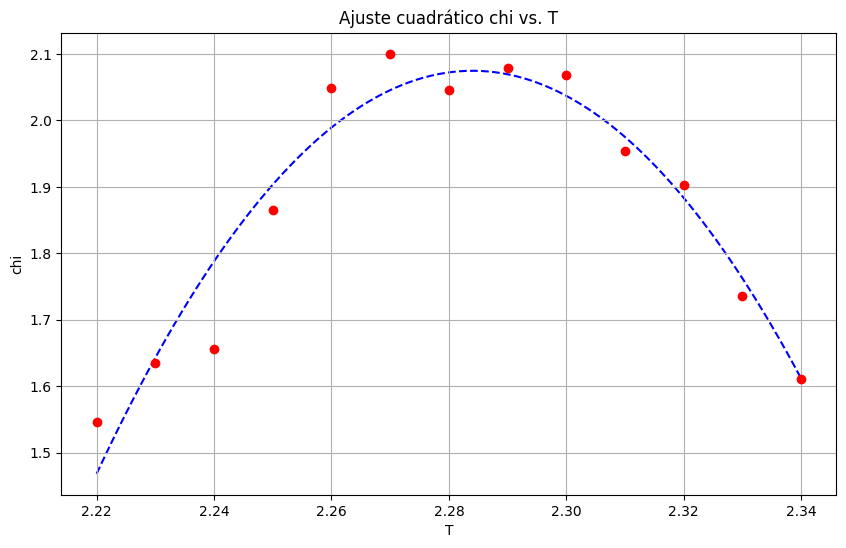

T_max = 2.2840345264046915 +/- 0.0015195283561218477


In [ ]:
# Cuadrada L = 50

df_cuad_50 = pd.read_csv('/content/ising_cuad_L50.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_cuad_50['Temperatura'], df_cuad_50['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_cuad_50['Temperatura'], df_cuad_50['Energia_por_sitio'], '.', color='tab:blue')
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_cuad_50['Temperatura'], df_cuad_50['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_cuad_50['Temperatura'], df_cuad_50['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturasA = np.arange(1.6, 2.0, 0.05)
temperaturascercanas= np.arange(2.0, 2.5, 0.01) # para ver la transición de fase con mayor detalle
temperaturasB = np.arange(2.5, 3.01, 0.05)
temperaturas = np.concatenate((temperaturasA, temperaturascercanas, temperaturasB))


df_cuad_teo_50 = pd.read_csv('/content/C_0050.csv')

plt.plot(df_cuad_teo_50.iloc[:, 0], df_cuad_teo_50.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_cuad_50['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 30
m = 43
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_cuad_50['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_cuad_50['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_L50 = T_max
err_Tc_L50 = sigma_Tmax

print("T_max =", Tc_L50, "+/-", err_Tc_L50)

### L = 64

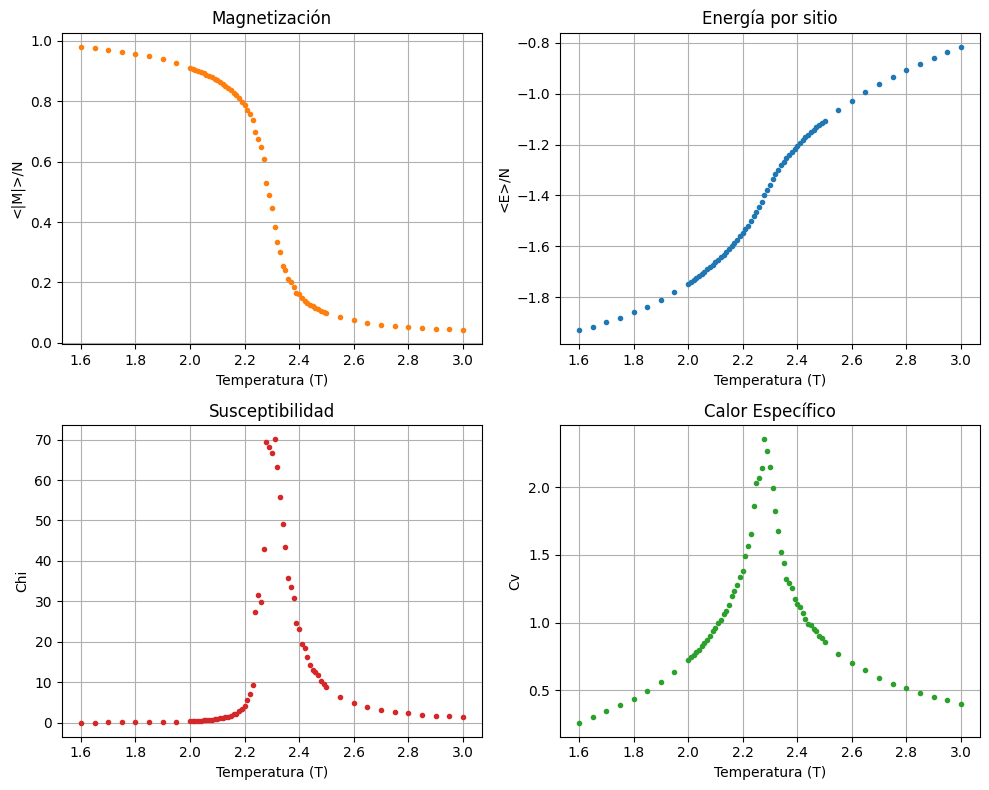

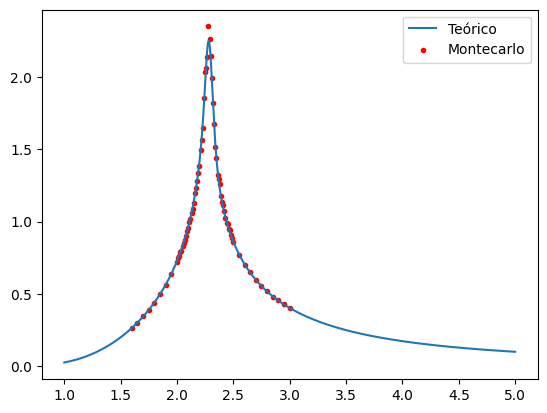

2.2798331595265897


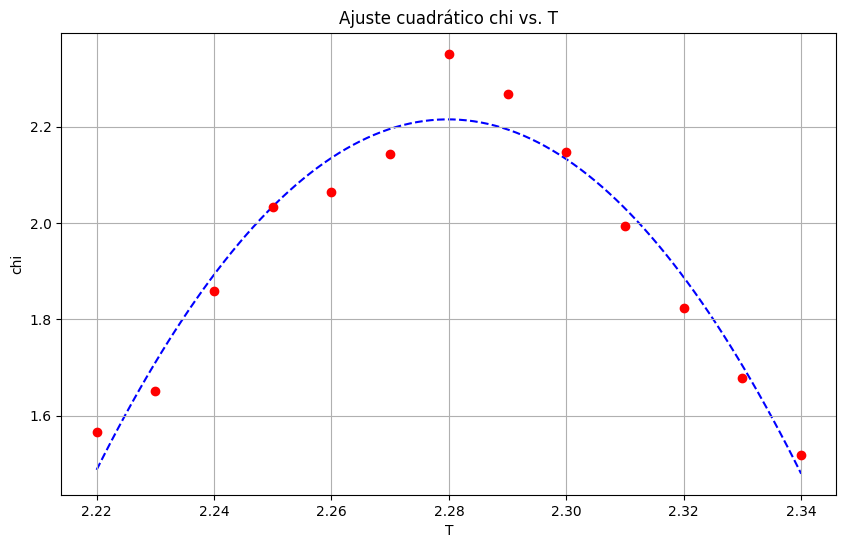

T_max = 2.2798331595265897 +/- 0.001290598231534544


In [ ]:
# Cuadrada L = 64

df_cuad_64 = pd.read_csv('/content/ising_cuad_L64.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_cuad_64['Temperatura'], df_cuad_64['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_cuad_64['Temperatura'], df_cuad_64['Energia_por_sitio'], '.', color='tab:blue')
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_cuad_64['Temperatura'], df_cuad_64['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_cuad_64['Temperatura'], df_cuad_64['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturasA = np.arange(1.6, 2.0, 0.05)
temperaturascercanas= np.arange(2.0, 2.5, 0.01) # para ver la transición de fase con mayor detalle
temperaturasB = np.arange(2.5, 3.01, 0.05)
temperaturas = np.concatenate((temperaturasA, temperaturascercanas, temperaturasB))


df_cuad_teo_64 = pd.read_csv('/content/C_0064.csv')

plt.plot(df_cuad_teo_64.iloc[:, 0], df_cuad_teo_64.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_cuad_64['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 30
m = 43
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_cuad_64['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_cuad_64['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_L64 = T_max
err_Tc_L64 = sigma_Tmax

print("T_max =", Tc_L64, "+/-", err_Tc_L64)

### L = 76

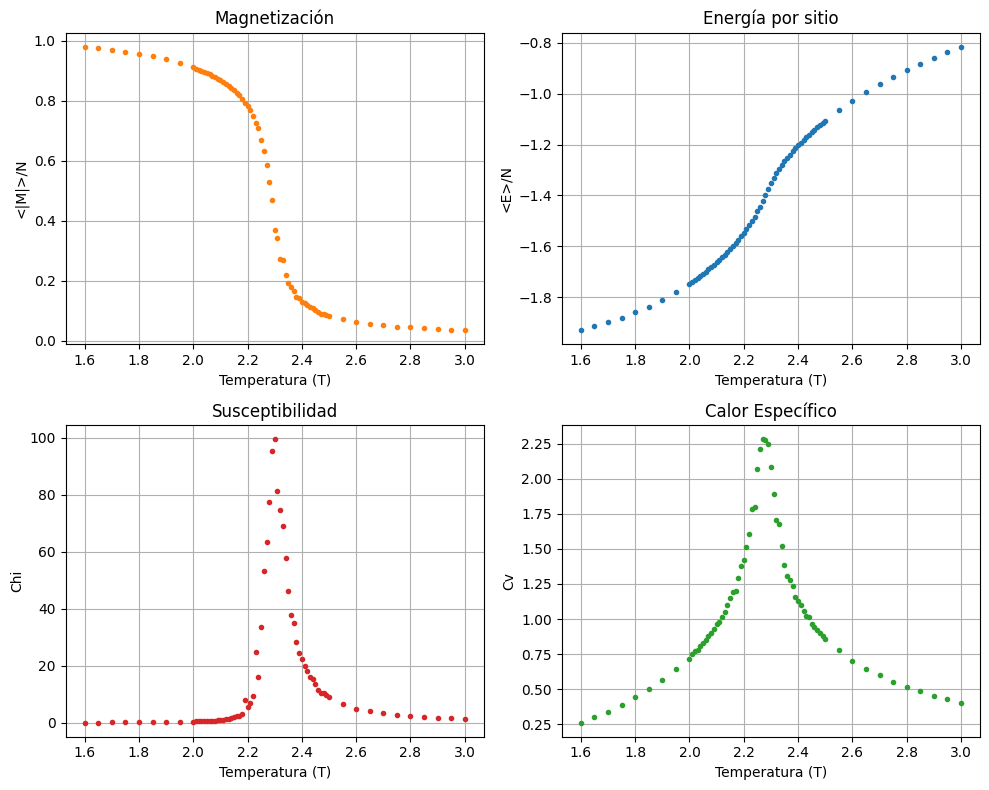

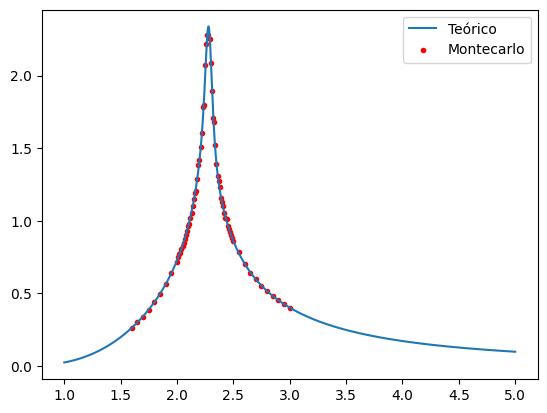

2.2769819044003983


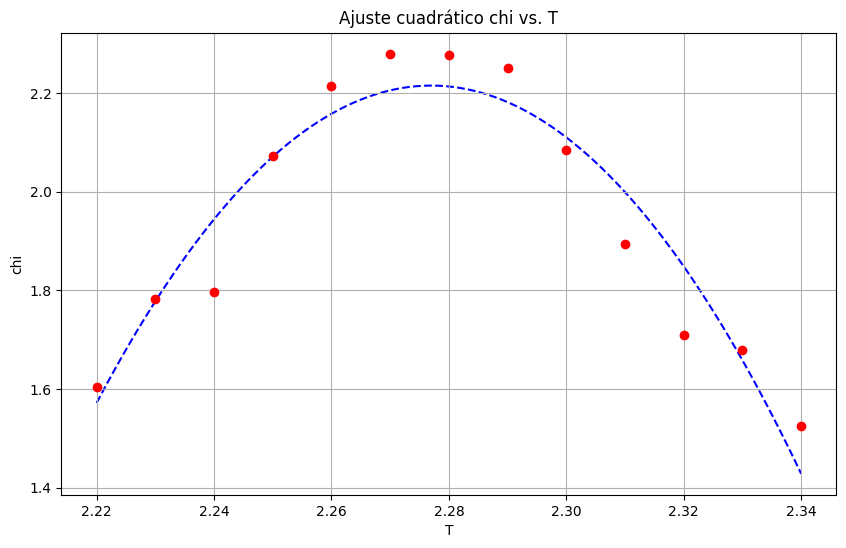

T_max = 2.2769819044003983 +/- 0.0017134845820263864


In [ ]:
# Cuadrada L = 76

df_cuad_76 = pd.read_csv('/content/ising_cuad_L76.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_cuad_76['Temperatura'], df_cuad_76['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_cuad_76['Temperatura'], df_cuad_76['Energia_por_sitio'], '.', color='tab:blue')
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_cuad_76['Temperatura'], df_cuad_76['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_cuad_76['Temperatura'], df_cuad_76['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturasA = np.arange(1.6, 2.0, 0.05)
temperaturascercanas= np.arange(2.0, 2.5, 0.01) # para ver la transición de fase con mayor detalle
temperaturasB = np.arange(2.5, 3.01, 0.05)
temperaturas = np.concatenate((temperaturasA, temperaturascercanas, temperaturasB))


df_cuad_teo_76 = pd.read_csv('/content/C_0076.csv')

plt.plot(df_cuad_teo_76.iloc[:, 0], df_cuad_teo_76.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_cuad_76['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 30
m = 43
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_cuad_76['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_cuad_76['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_L76 = T_max
err_Tc_L76 = sigma_Tmax

print("T_max =", Tc_L76, "+/-", err_Tc_L76)

### L = 86

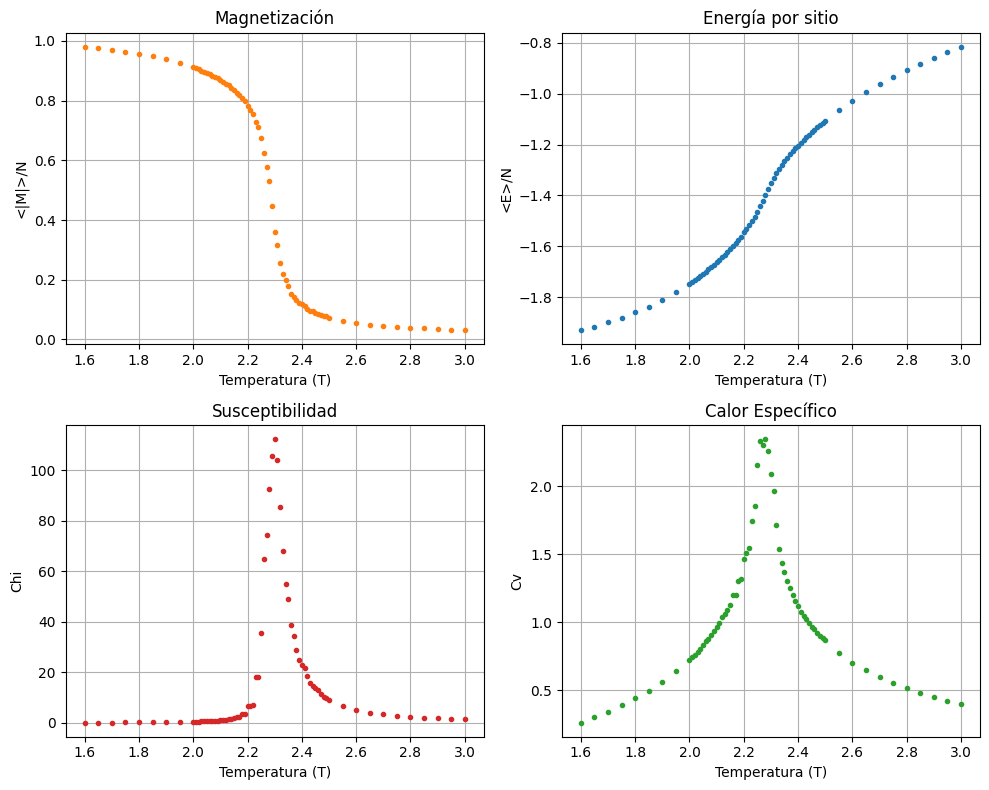

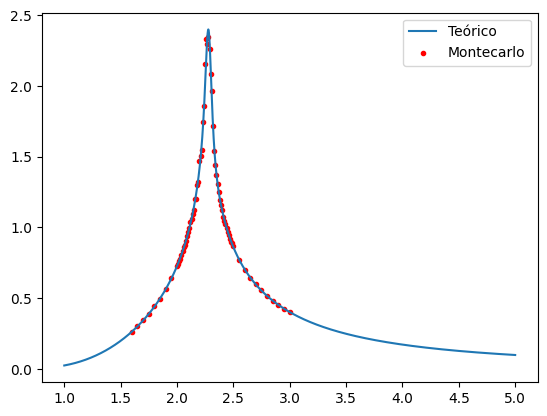

2.2761703619884894


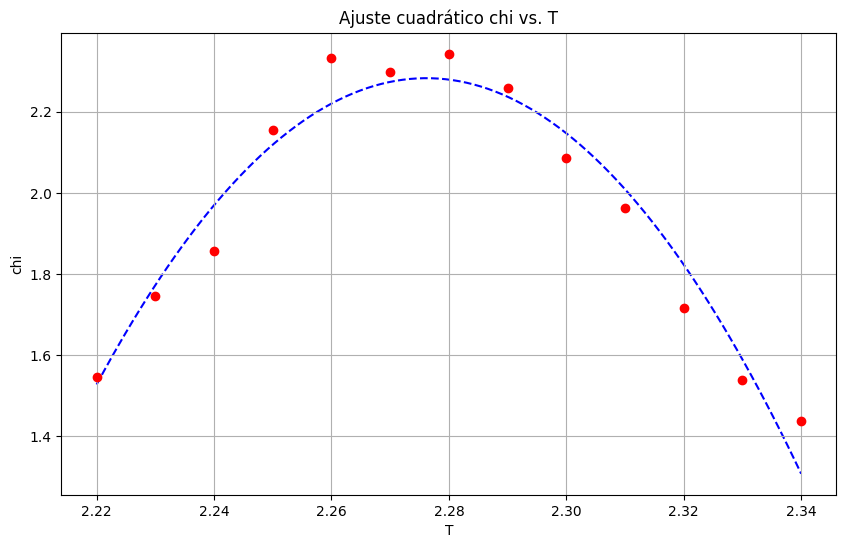

T_max = 2.2761703619884894 +/- 0.001326155721915302


In [ ]:
# Cuadrada L = 86

df_cuad_86 = pd.read_csv('/content/ising_cuad_L86.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_cuad_86['Temperatura'], df_cuad_86['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_cuad_86['Temperatura'], df_cuad_86['Energia_por_sitio'], '.', color='tab:blue')
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_cuad_86['Temperatura'], df_cuad_86['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_cuad_86['Temperatura'], df_cuad_86['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturasA = np.arange(1.6, 2.0, 0.05)
temperaturascercanas= np.arange(2.0, 2.5, 0.01) # para ver la transición de fase con mayor detalle
temperaturasB = np.arange(2.5, 3.01, 0.05)
temperaturas = np.concatenate((temperaturasA, temperaturascercanas, temperaturasB))


df_cuad_teo_86 = pd.read_csv('/content/C_0086.csv')

plt.plot(df_cuad_teo_86.iloc[:, 0], df_cuad_teo_86.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_cuad_86['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 30
m = 43
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_cuad_86['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_cuad_86['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_L86 = T_max
err_Tc_L86 = sigma_Tmax

print("T_max =", Tc_L86, "+/-", err_Tc_L86)

## Ajuste temperatura crítica (Tc)

---



| L  | Tc     | Error     |
|----|-------|-------|
| 10|  2.347 | 0.001 |
| 13|  2.329 | 0.001 |
| 20|  2.308 | 0.002 |
| 25|  2.299 | 0.002 |
| 30| 2.294 | 0.002 |
| 33|  2.290 | 0.002 |
| 44| 2.284 | 0.001 |
| 50| 2.284  | 0.002 |
|64 | 2.281 |0.003 |
|76 | 2.278 | 0.003 |
|86 | 2.277 | 0.003 |

La relación observada en la siguiente celda es $T_c(L) = T_c(\infty) + \frac{a}{L}$, donde $T_c$ es la temperatura de transición en el límite termodinámico, cuando $L →\infty$, donde ocurre verdaderamente la transición de fase.


<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-4081442969.py:19: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x_fit, y_fit, '--b', label = f'$T_c = ({b_opt:.6f} \pm {error_b:.6f})$')


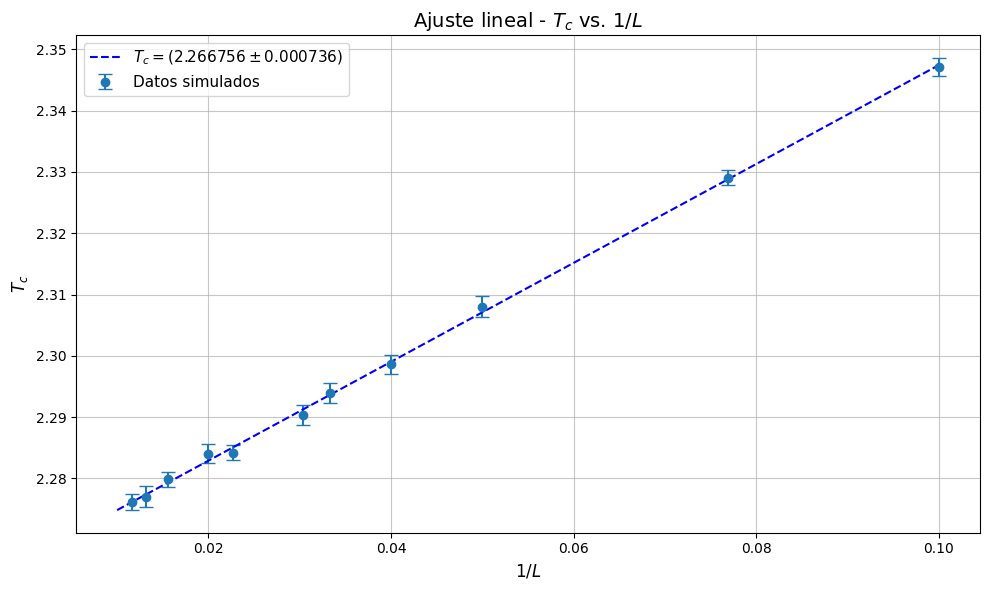

In [ ]:
L_values = np.array([10, 13, 20, 25, 30, 33, 44, 50, 64, 76, 86])
Tc_values = np.array([Tc_L10, Tc_L13, Tc_L20, Tc_L25, Tc_L30, Tc_L33, Tc_L44, Tc_L50, Tc_L64, Tc_L76, Tc_L86])
Error_values = np.array([err_Tc_L10, err_Tc_L13, err_Tc_L20, err_Tc_L25, err_Tc_L30, err_Tc_L33, err_Tc_L44, err_Tc_L50, err_Tc_L64, err_Tc_L76, err_Tc_L86])

inv_L = 1 / L_values


popt, pcov = curve_fit(lineal, inv_L, Tc_values, sigma=Error_values, absolute_sigma=True)
m_opt, b_opt = popt
error_b = np.sqrt(pcov[1, 1])

plt.figure(figsize=(10, 6))

plt.errorbar(inv_L, Tc_values, yerr=Error_values, fmt='o', capsize=5, label='Datos simulados', markersize=6)

x_fit = np.linspace(0.01, inv_L.max() , 100)
y_fit = lineal(x_fit, m_opt, b_opt)

plt.plot(x_fit, y_fit, '--b', label = f'$T_c = ({b_opt:.6f} \pm {error_b:.6f})$')

plt.title('Ajuste lineal - $T_c$ vs. $1/L$', fontsize=14)
plt.xlabel('$1/L$', fontsize=12)
plt.ylabel('$T_c$', fontsize=12)
plt.grid(True, linestyle='-', alpha=0.7)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()



#Red hexagonal

##Hamiltoniano
Para embeber la red hexagonal en una rectangular lo que hicimos fue pensar la red hexagonal como una rectangular de primeros vecinos con interacciones apagadas. Similar a como trabajamos con grafos en la primera mitad pensando en aristas encendidas u apagadas.
Como se ve en la imagen a modo de ilustracion para la red 1 x 1 los vecinos 2-6 y 4-8 no tienen interacción de primeros vecinos en la hexagonal por lo tanto su interaccion en la rectangular (marcada con rojo) no debe considerarse.
La otra consideración es relativa al tamaño de la red rectangular. El número de columnas son los spines por lado y el número de filas la cantidad de "lineas horizontales en ziz zag" que se observan;en la red 1x1 una linea esta formada por 1,2,3,4 y la otra por 5,6,7,8; y en la red 3 x 3 son cuatro las serpientes: 1-8,9-16,17-24,25-32.
En general, en terminos de N x N = Nro de Hexágonos resulta que: Filas = N + 1 y Columnas = 2 x (N+1).
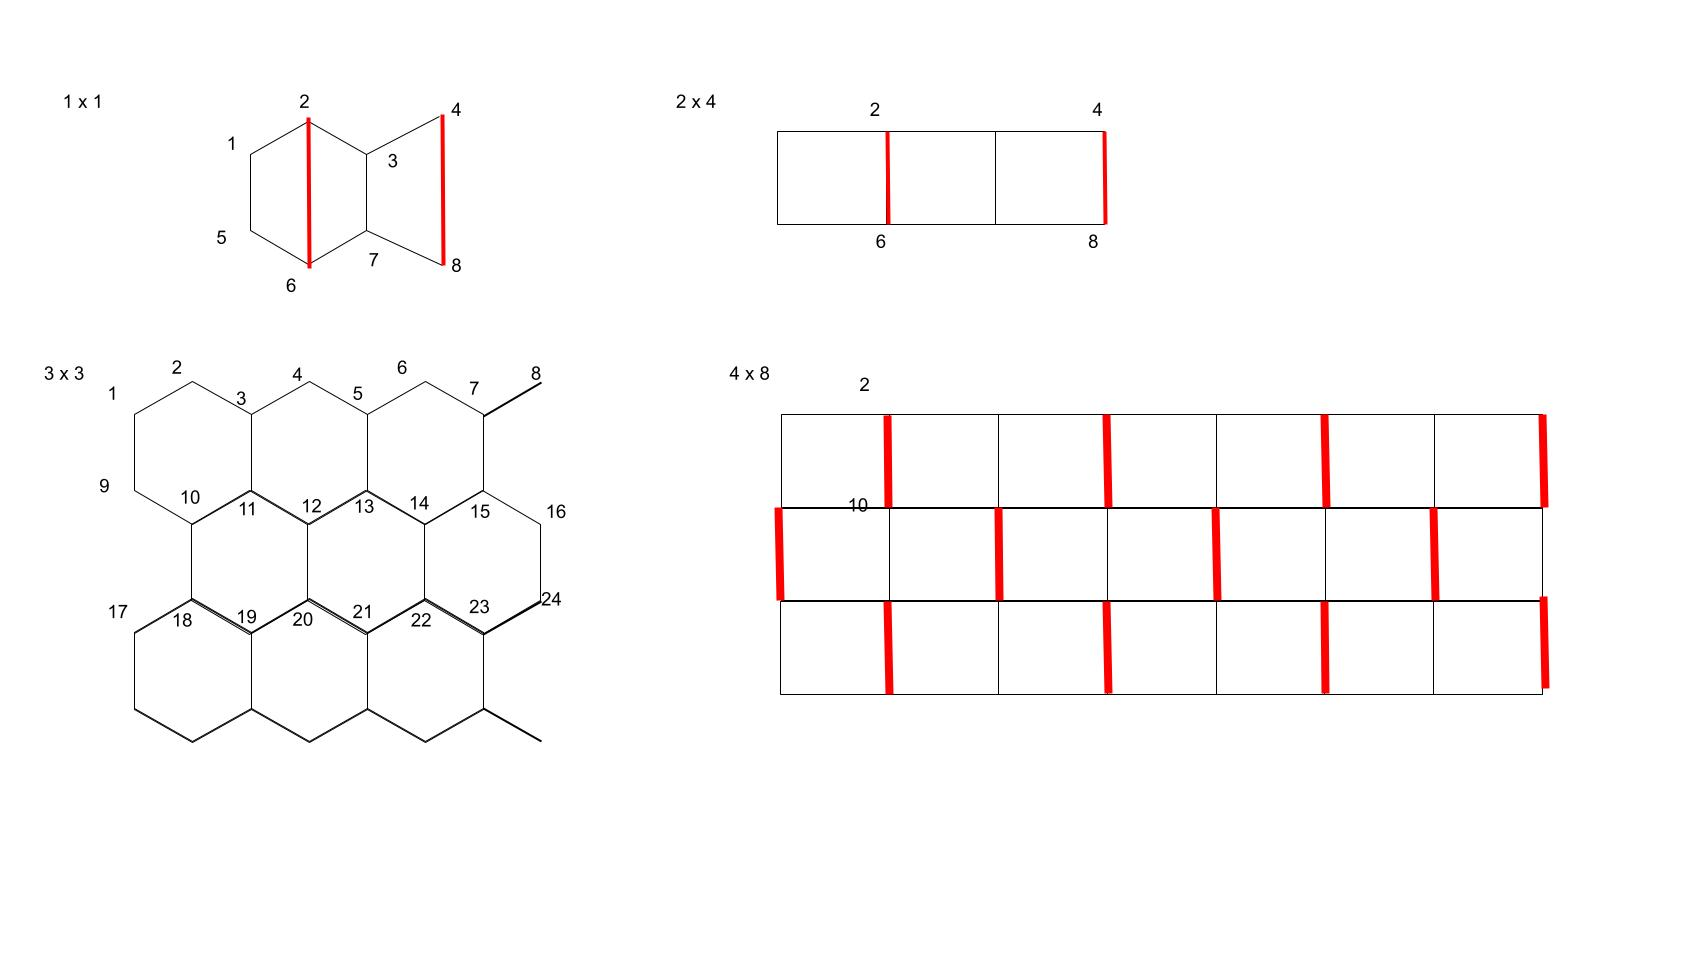

###
Para implementar qué interacciones debian apagarse fue preciso notar que las interacciones apagadas se alternaban y estaban corridas en una posición por fila, de modo que se cumplia la regla de que cuando (i,j) ambos eran pares o impares entonces  tenia los vecinos de los costados pero únicamente el de arriba mientras que si (i,j) era uno par y otro impar interactua con los vecinos de los costados y con el de abajo. Si llamamos A al primer caso y B al otro, con estas consideraciones podemos corregir el Hamiltoniano de la red plana pidiendole que en el caso A en la energia sólo cuente la interacción con el vecino de la izquierda y en el caso B que cuente la interacción con el de la izquierda y el de arriba.
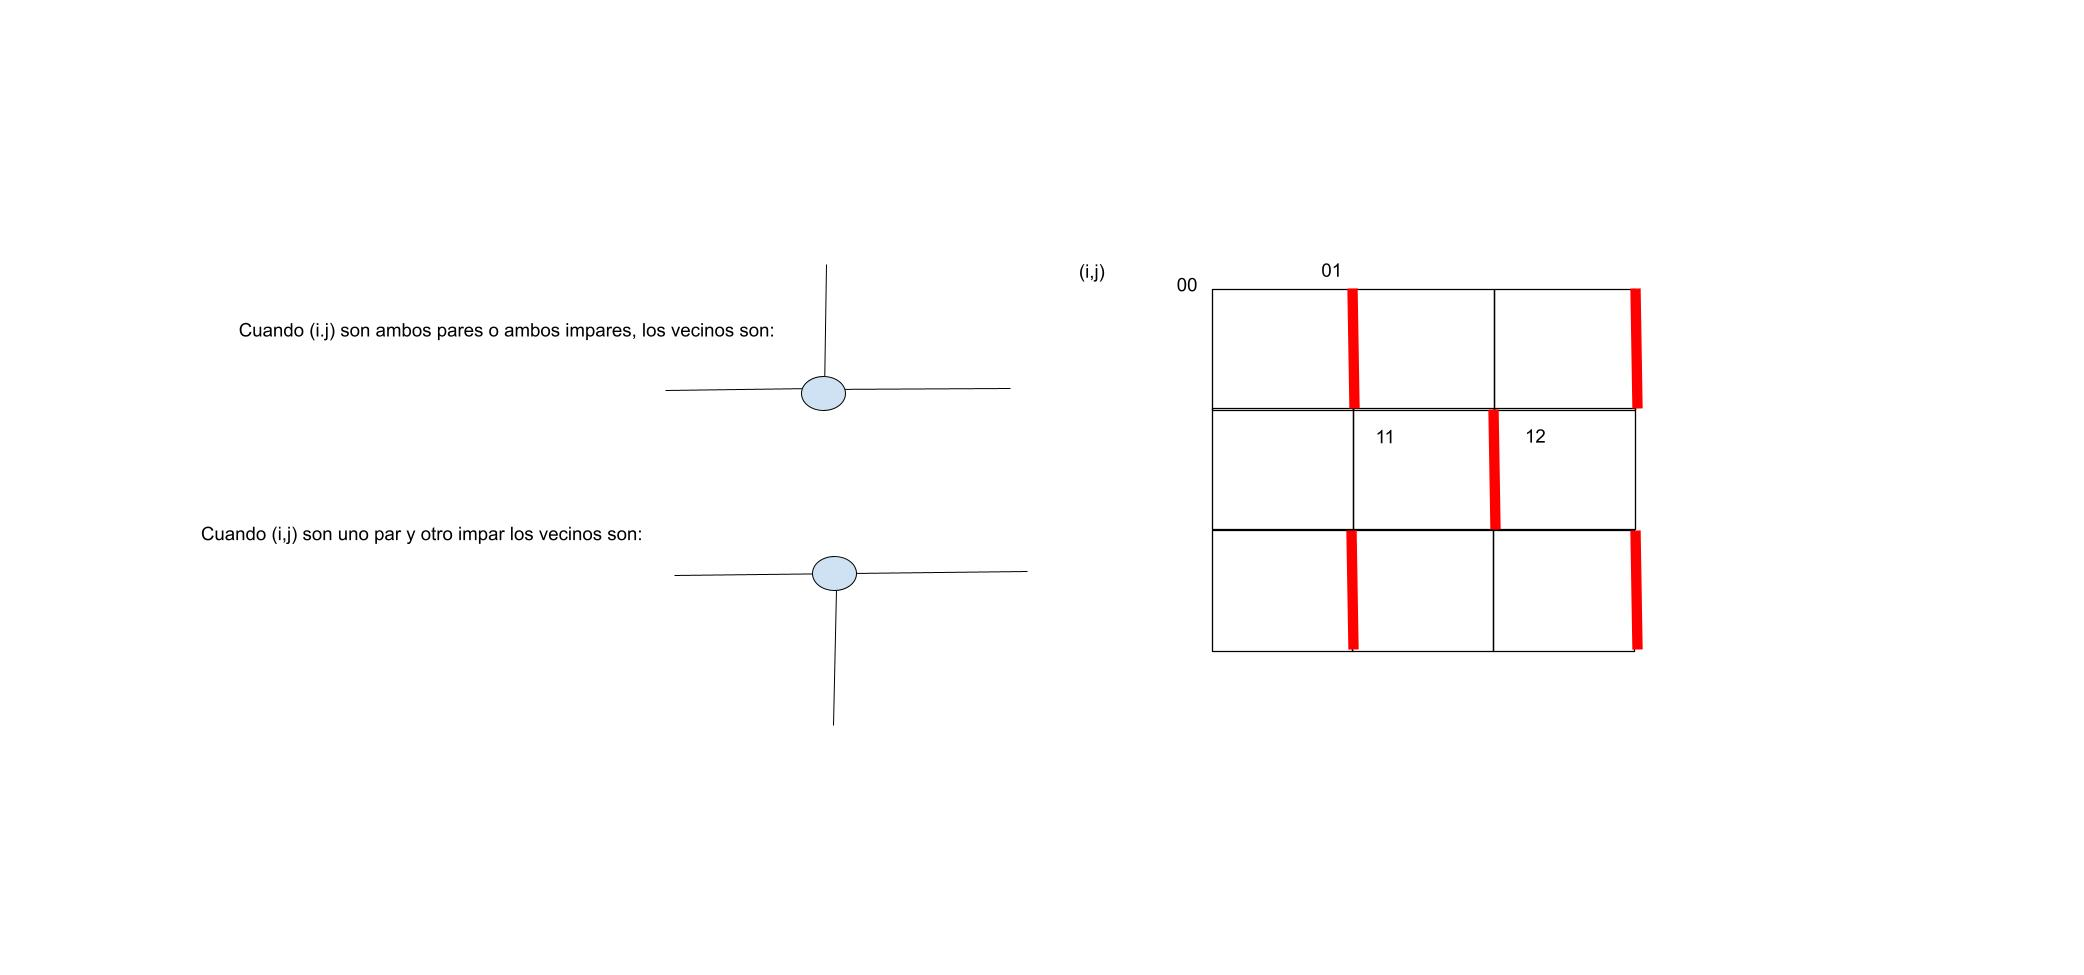


In [ ]:
@njit
def h(S):
    L = S.shape[0]
    C = S.shape[1]
    energia = 0.0
    for i in range(L):
        for j in range(C):
            s = S[i, j]
            izquierda = S[i, (j-1) % C]
            if (i+j) % 2 != 0: # Impar
                arriba = S[(i-1) % L, j]
                energia += s * (arriba + izquierda)
            else:              # Par
                energia += s * izquierda

    return -energia


# Funciones

In [ ]:
@njit
def realizar_barrido_metropolis(S, prob2, prob6):
    """Realiza un barrido completo (L*C intentos) para actualizar S."""
    L = S.shape[0]
    C = S.shape[1]
    L2 = L * C

    for _ in range(L2):
        r = np.random.randint(L2)
        i, j = divmod(r, C)
        s_actual = S[i, j]

        izquierda = S[i, (j - 1) % C]
        derecha   = S[i, (j + 1) % C]

        if (i + j) % 2 == 0: # sitio PAR
            abajo = S[(i + 1) % L, j]
            suma_vecinos = abajo + izquierda + derecha
        else:               # sitio IMPAR
            arriba = S[(i - 1) % L, j]
            suma_vecinos = arriba + izquierda + derecha

        dE = 2 * s_actual * suma_vecinos

        aceptado = False
        if dE <= 0:
            aceptado = True
        else:
            r_rand = np.random.random()
            if dE == 2:
                if r_rand < prob2: aceptado = True
            elif dE == 6:
                if r_rand < prob6: aceptado = True

        if aceptado:
            S[i, j] = -s_actual

In [ ]:
# Termalización
@njit
def termalizar(S, prob2, prob6, pasos):
    for _ in range(pasos):
        realizar_barrido_metropolis(S, prob2, prob6)

def termalizar_con_print(S, prob2, prob6, pasos):
    for k in range(pasos):
        termalizar(S, prob2, prob6, 1)   # corre de a 1 paso
        if k % 50000 == 0:
            print(f"Simulando ando")

In [ ]:
# Medición
@njit
def medir_seguro(S, prob2, prob6, pasos_medicion):
    pasos_reales = pasos_medicion // 10 # Medimos cada 10 barridos para reducir autocorrelación
    m_vals = np.zeros(pasos_reales)
    e_vals = np.zeros(pasos_reales)

    idx = 0
    for k in range(pasos_medicion):

        realizar_barrido_metropolis(S, prob2, prob6)

        if k % 10 == 0:

            e_vals[idx] = h(S)
            m_vals[idx] = np.sum(S)
            idx += 1

    e_mean = np.mean(e_vals)
    m_abs_mean = np.mean(np.abs(m_vals))
    e_var = np.var(e_vals)
    m_abs_var = np.var(np.abs(m_vals))

    return m_abs_mean, e_mean, m_abs_var, e_var

**A CONTINUACIÓN, OTRAS SIETE SIMULACIONES. AHORA DE REDES HEXAGONALES DE DISTINTO TAMAÑO. NUEVAMENTE, EN 300.000 PASOS.**


## Redes

###L=10

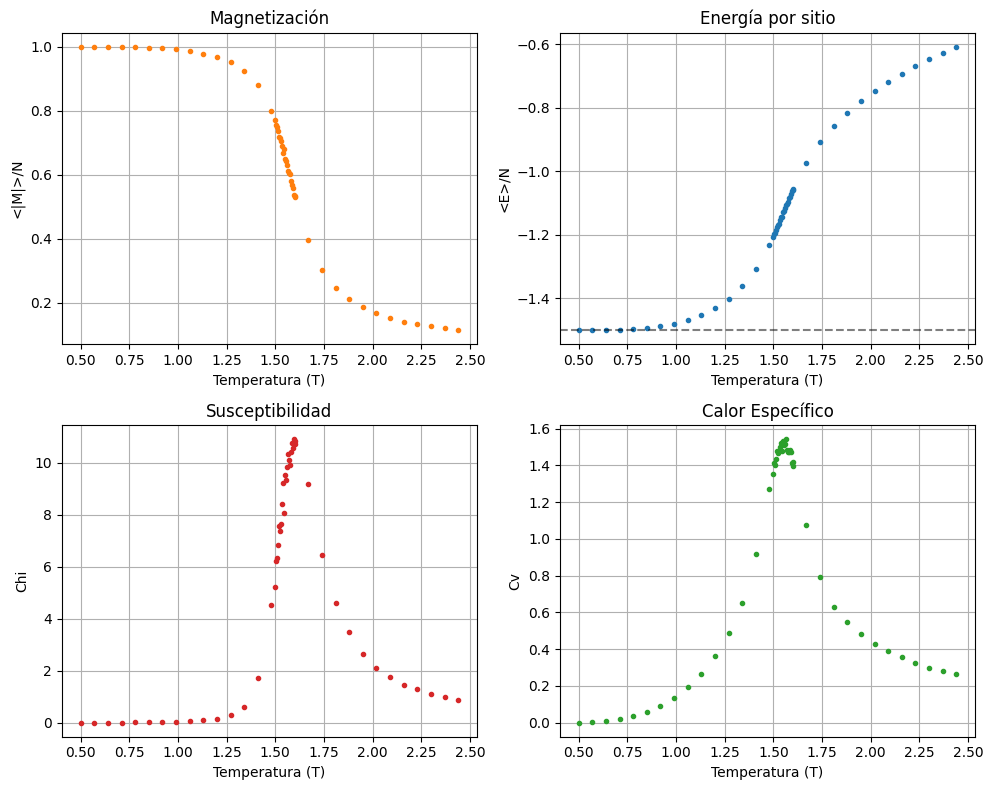

1.5542151725196134


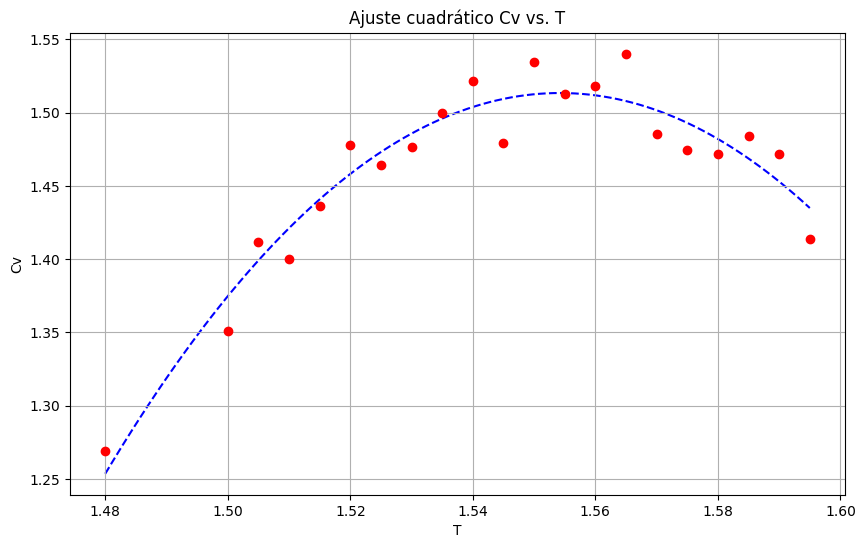

T_max = 1.5542151725196134 +/- 0.0017664464509190678


In [ ]:
L = 10


df_hex = pd.read_csv(f'/content/ising_hex_L{L}.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_hex['Temperatura'], df_hex['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_hex['Temperatura'], df_hex['Energia_por_sitio'], '.', color='tab:blue')
plt.axhline(-1.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_hex['Temperatura'], df_hex['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_hex['Temperatura'], df_hex['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturas = np.concatenate((
    np.arange(0.5, 1.5, 0.07),
    np.arange(1.5, 1.6, 0.005),
    np.arange(1.6, 2.5, 0.07)
))


n = 14
m = 35
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_hex['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
y_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)

plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_hex['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, y_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático Cv vs. T')
plt.xlabel('T')
plt.ylabel('Cv')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0, 0]
sigma_b2 = pcov[1, 1]
sigma_ab = pcov[0, 1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_10 = T_max
err_Tc_10 = sigma_Tmax

print("T_max =", Tc_10, "+/-", err_Tc_10)

###L=12

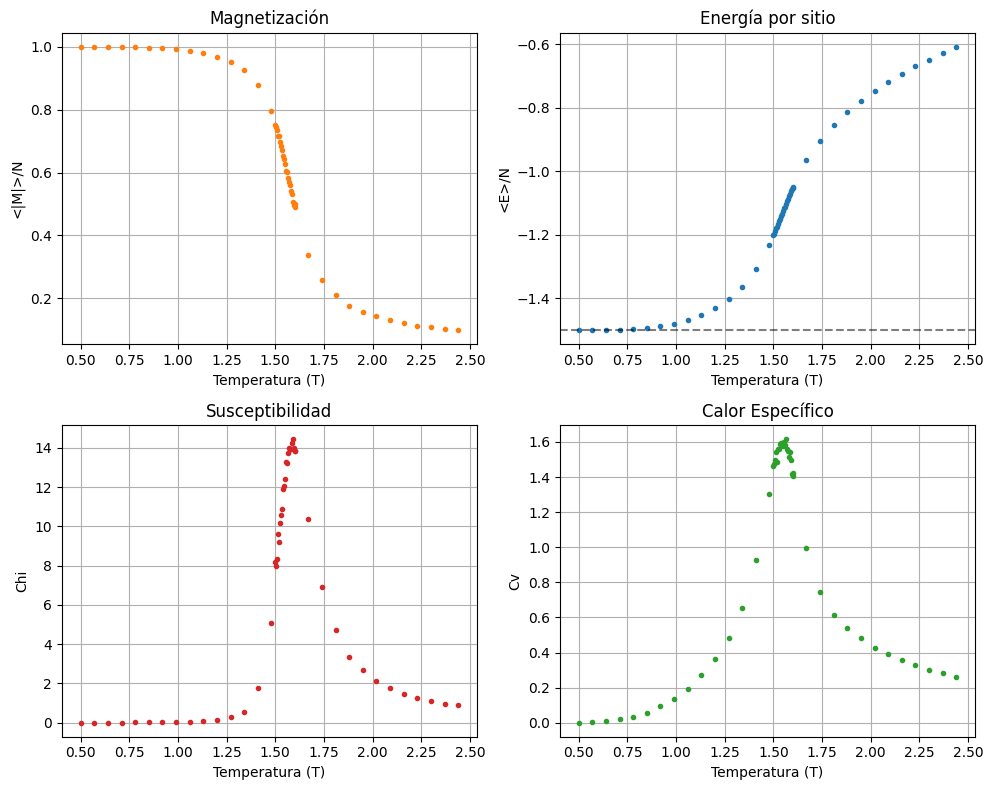

1.548440252131551


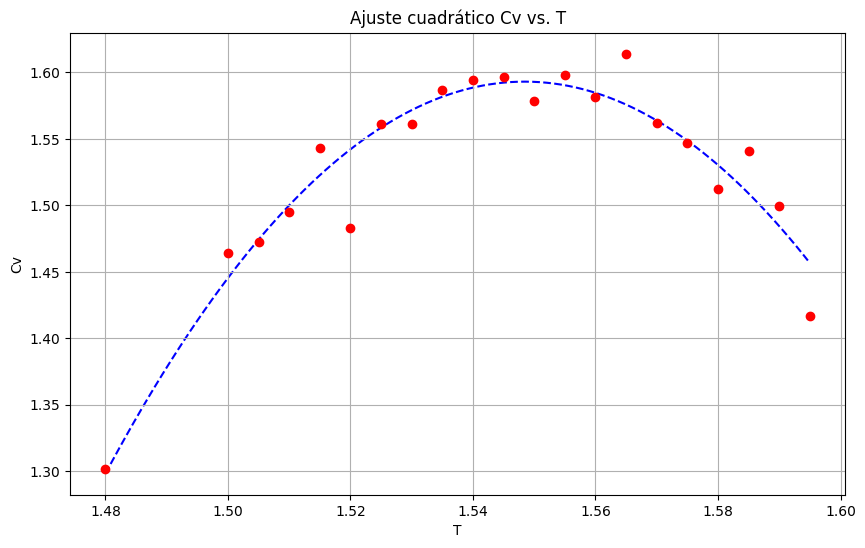

T_max = 1.548440252131551 +/- 0.0013566598180396964


In [ ]:
L = 12


df_hex = pd.read_csv(f'/content/ising_hex_L{L}.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_hex['Temperatura'], df_hex['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_hex['Temperatura'], df_hex['Energia_por_sitio'], '.', color='tab:blue')
plt.axhline(-1.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_hex['Temperatura'], df_hex['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_hex['Temperatura'], df_hex['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturas = np.concatenate((
    np.arange(0.5, 1.5, 0.07),
    np.arange(1.5, 1.6, 0.005),
    np.arange(1.6, 2.5, 0.07)
))


n = 14
m = 35
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_hex['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
y_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)

plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_hex['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, y_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático Cv vs. T')
plt.xlabel('T')
plt.ylabel('Cv')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0, 0]
sigma_b2 = pcov[1, 1]
sigma_ab = pcov[0, 1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_12 = T_max
err_Tc_12 = sigma_Tmax

print("T_max =", Tc_12, "+/-", err_Tc_12)

###L=15

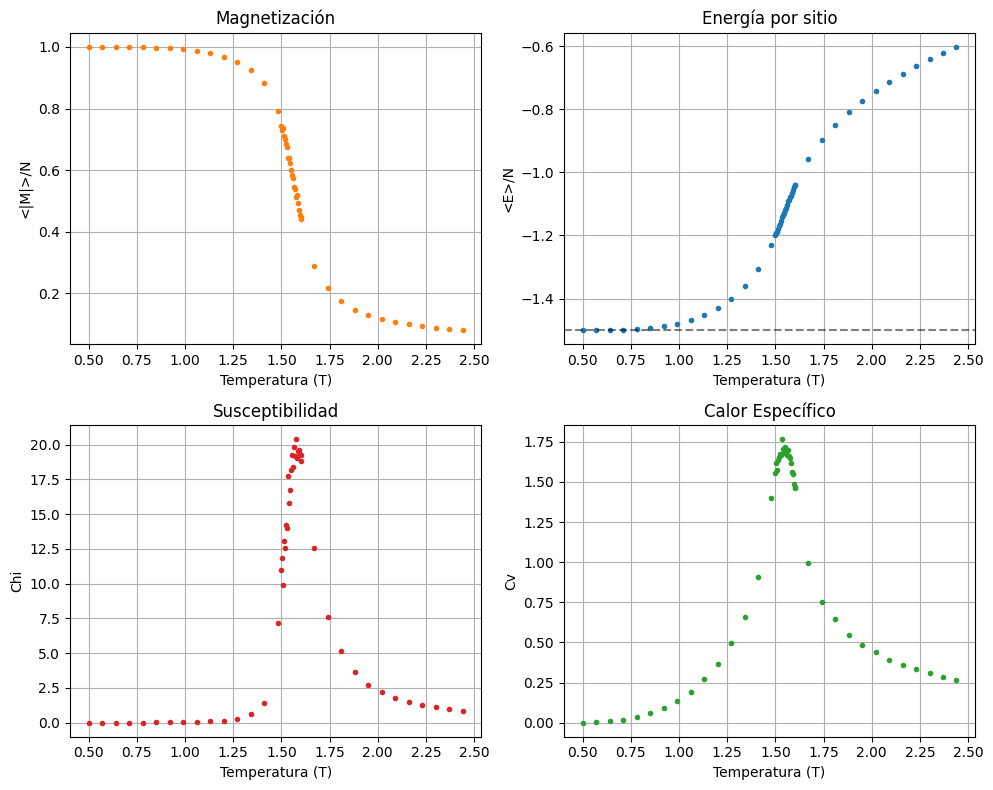

1.5440862861591258


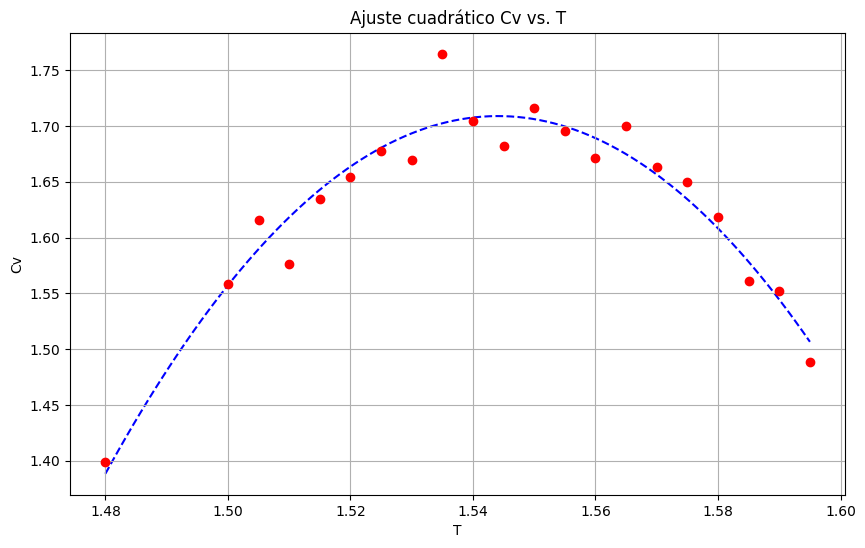

T_max = 1.5440862861591258 +/- 0.0010582150133077808


In [ ]:
L = 15

df_hex = pd.read_csv(f'/content/ising_hex_L{L}.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_hex['Temperatura'], df_hex['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_hex['Temperatura'], df_hex['Energia_por_sitio'], '.', color='tab:blue')
plt.axhline(-1.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_hex['Temperatura'], df_hex['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_hex['Temperatura'], df_hex['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturas = np.concatenate((
    np.arange(0.5, 1.5, 0.07),
    np.arange(1.5, 1.6, 0.005),
    np.arange(1.6, 2.5, 0.07)
))


n = 14
m = 35
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_hex['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
y_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)

plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_hex['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, y_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático Cv vs. T')
plt.xlabel('T')
plt.ylabel('Cv')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0, 0]
sigma_b2 = pcov[1, 1]
sigma_ab = pcov[0, 1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_15 = T_max
err_Tc_15 = sigma_Tmax

print("T_max =", Tc_15, "+/-", err_Tc_15)

###L=16

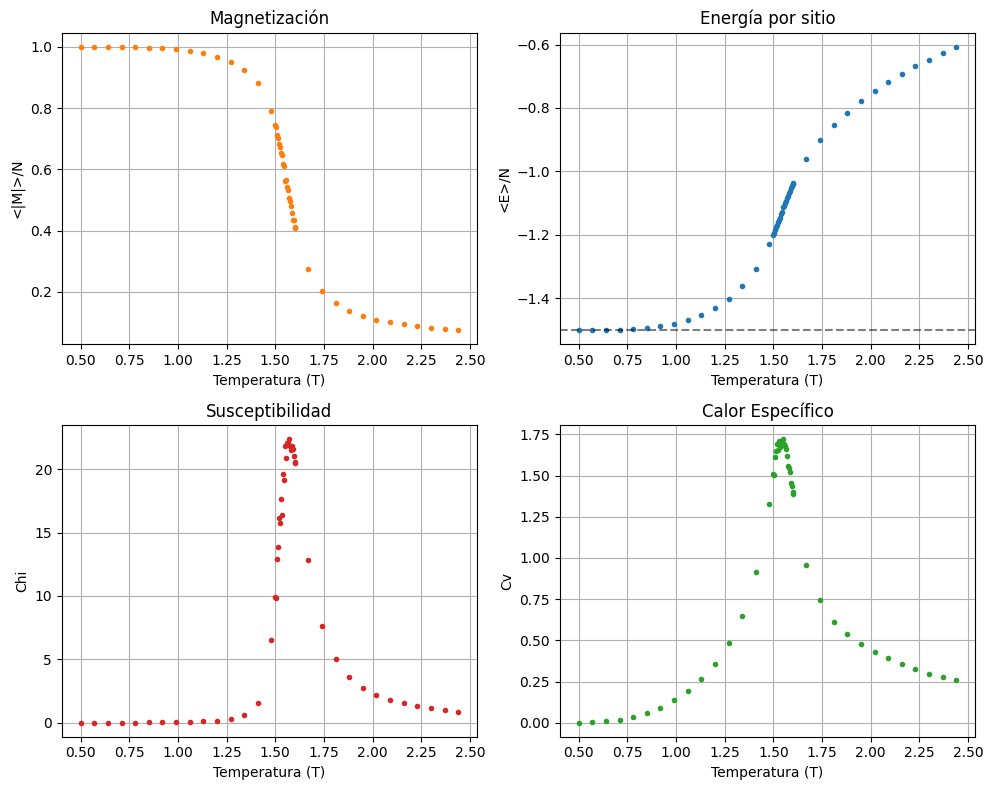

1.54201422571524


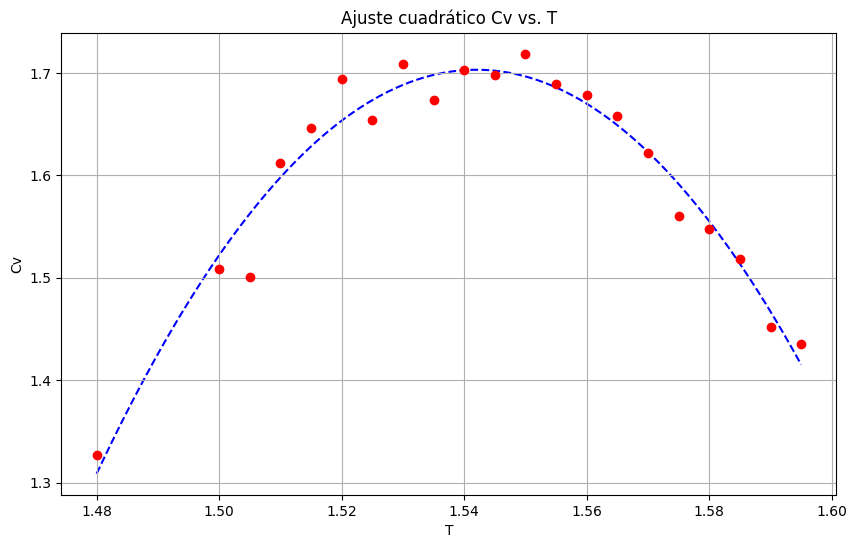

T_max = 1.54201422571524 +/- 0.0008053550209944938


In [ ]:
L = 16


df_hex = pd.read_csv(f'/content/ising_hex_L{L}.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_hex['Temperatura'], df_hex['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_hex['Temperatura'], df_hex['Energia_por_sitio'], '.', color='tab:blue')
plt.axhline(-1.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_hex['Temperatura'], df_hex['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_hex['Temperatura'], df_hex['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturas = np.concatenate((
    np.arange(0.5, 1.5, 0.07),
    np.arange(1.5, 1.6, 0.005),
    np.arange(1.6, 2.5, 0.07)
))


n = 14
m = 35
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_hex['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
y_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)

plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_hex['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, y_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático Cv vs. T')
plt.xlabel('T')
plt.ylabel('Cv')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0, 0]
sigma_b2 = pcov[1, 1]
sigma_ab = pcov[0, 1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_16 = T_max
err_Tc_16 = sigma_Tmax

print("T_max =", Tc_16, "+/-", err_Tc_16)

###L=20

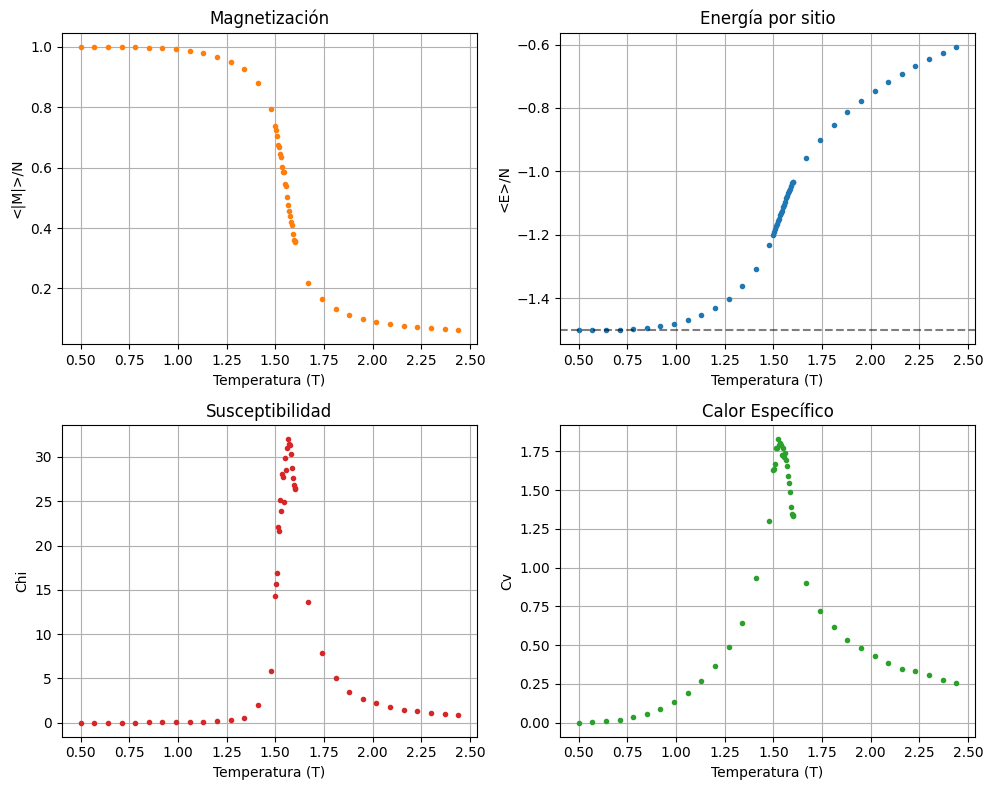

1.5374039673779751


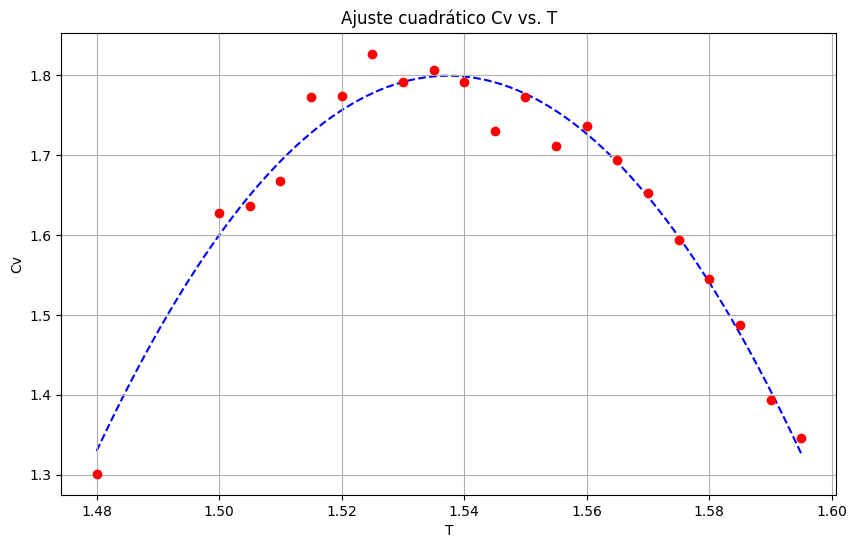

T_max = 1.5374039673779751 +/- 0.0006961005043505137


In [ ]:
L = 20


df_hex = pd.read_csv(f'/content/ising_hex_L{L}.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_hex['Temperatura'], df_hex['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_hex['Temperatura'], df_hex['Energia_por_sitio'], '.', color='tab:blue')
plt.axhline(-1.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_hex['Temperatura'], df_hex['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_hex['Temperatura'], df_hex['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturas = np.concatenate((
    np.arange(0.5, 1.5, 0.07),
    np.arange(1.5, 1.6, 0.005),
    np.arange(1.6, 2.5, 0.07)
))

n = 14
m = 35
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_hex['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
y_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)

plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_hex['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, y_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático Cv vs. T')
plt.xlabel('T')
plt.ylabel('Cv')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0, 0]
sigma_b2 = pcov[1, 1]
sigma_ab = pcov[0, 1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_20 = T_max
err_Tc_20 = sigma_Tmax

print("T_max =", Tc_20, "+/-", err_Tc_20)

###L=22

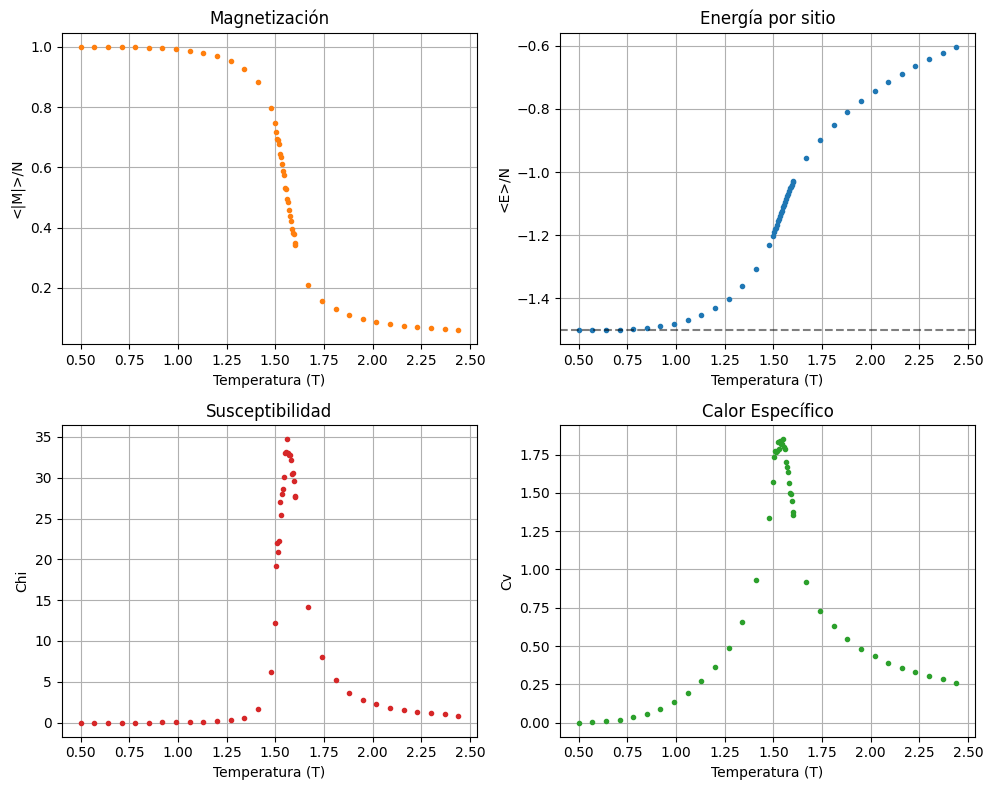

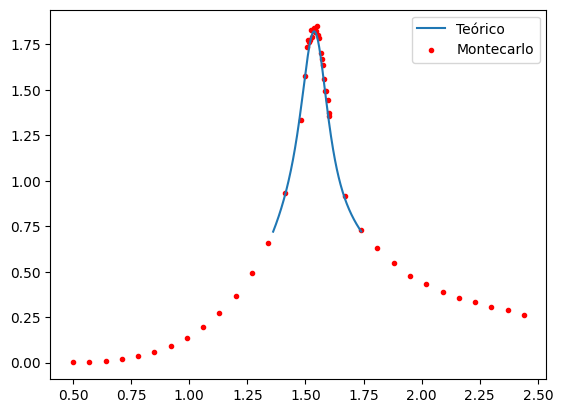

1.5384992299289721


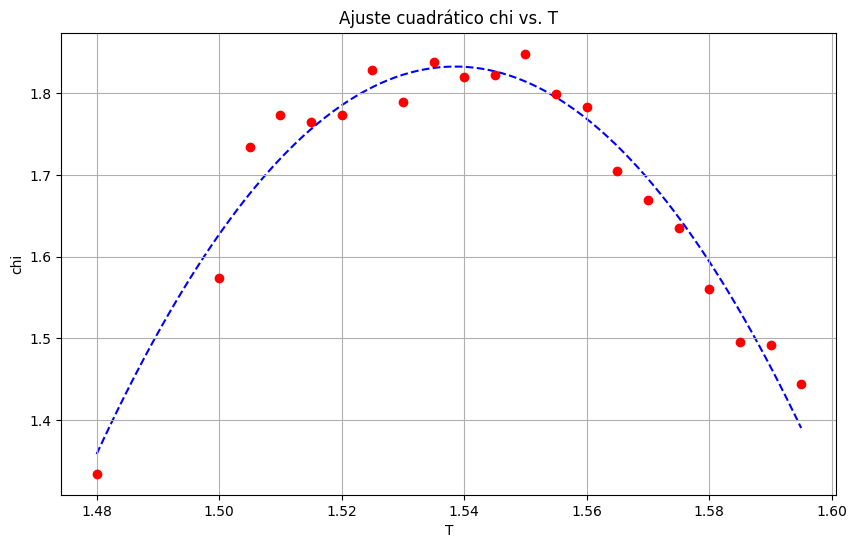

T_max = 1.5384992299289721 +/- 0.0008635815295413369


In [ ]:
# Hexagonal N = 22

df_hex_22 = pd.read_csv('/content/ising_hex_L22.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_hex_22['Temperatura'], df_hex_22['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_hex_22['Temperatura'], df_hex_22['Energia_por_sitio'], '.', color='tab:blue')
plt.axhline(-1.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_hex_22['Temperatura'], df_hex_22['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_hex_22['Temperatura'], df_hex_22['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturas = np.concatenate((
    np.arange(0.5, 1.5, 0.07),
    np.arange(1.5, 1.6, 0.005),
    np.arange(1.6, 2.5, 0.07)
))


df_hex_teo_22 = pd.read_csv('/content/c_22x22.csv')

plt.plot(df_hex_teo_22.iloc[:, 0], df_hex_teo_22.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_hex_22['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 14
m = 35
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_hex_22['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_hex_22['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_22 = T_max
err_Tc_22 = sigma_Tmax

print("T_max =", Tc_22, "+/-", err_Tc_22)

### L=34


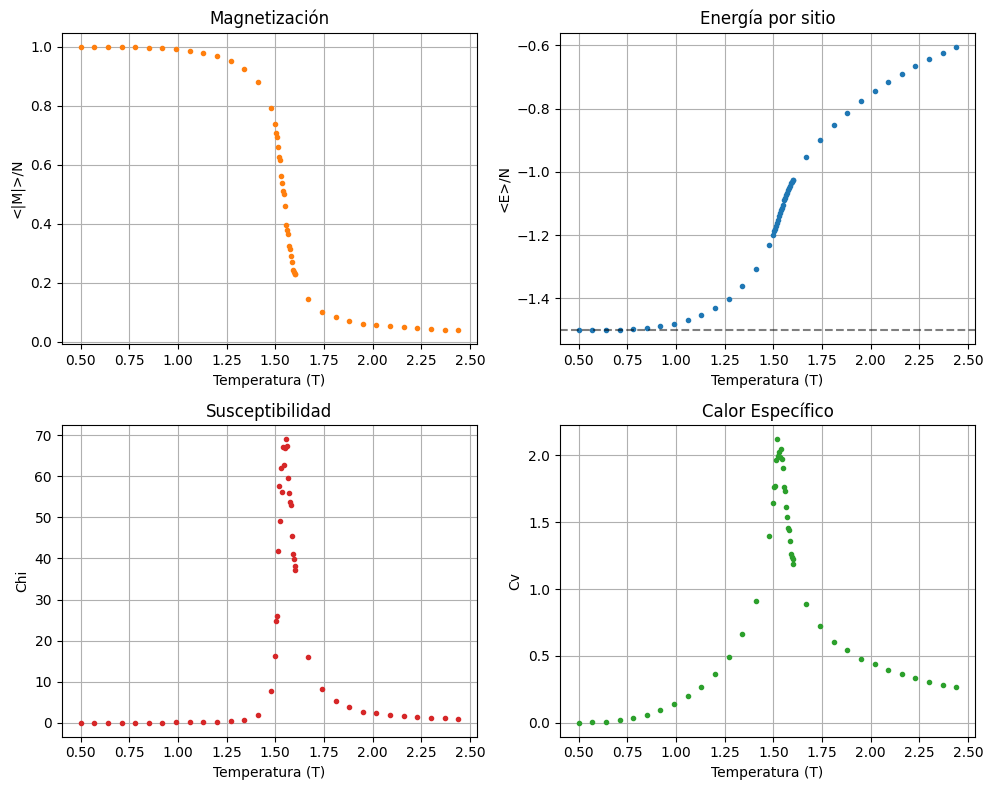

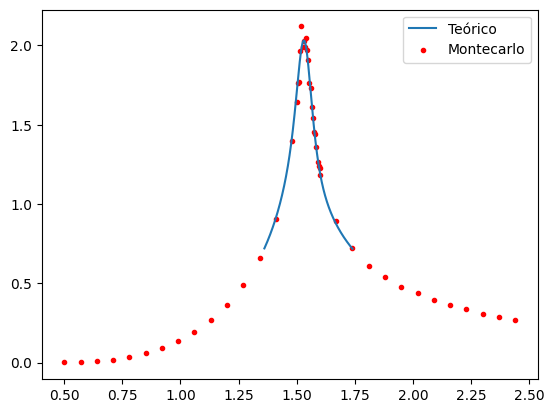

1.5319151062213434


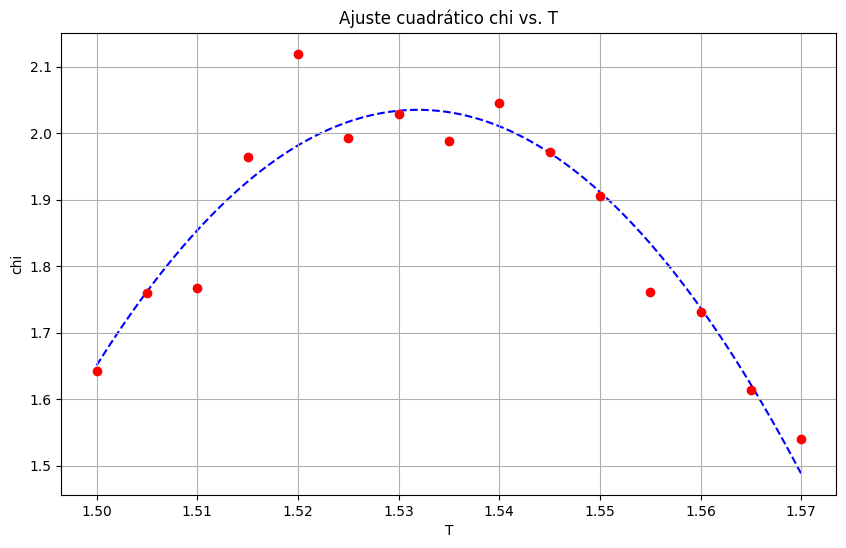

T_max = 1.5319151062213434 +/- 0.0009594520926749354


In [ ]:
# Hexagonal N = 34

df_hex_34 = pd.read_csv('/content/ising_hex_L34.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_hex_34['Temperatura'], df_hex_34['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_hex_34['Temperatura'], df_hex_34['Energia_por_sitio'], '.', color='tab:blue')
plt.axhline(-1.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_hex_34['Temperatura'], df_hex_34['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_hex_34['Temperatura'], df_hex_34['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturas = np.concatenate((
    np.arange(0.5, 1.5, 0.07),
    np.arange(1.5, 1.6, 0.005),
    np.arange(1.6, 2.5, 0.07)
))


df_hex_teo_34 = pd.read_csv('/content/c_34x34.csv')

plt.plot(df_hex_teo_34.iloc[:, 0], df_hex_teo_34.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_hex_34['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 15
m = 30
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_hex_34['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)
plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_hex_34['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_34 = T_max
err_Tc_34 = sigma_Tmax

print("T_max =", Tc_34, "+/-", err_Tc_34)

###L= 44

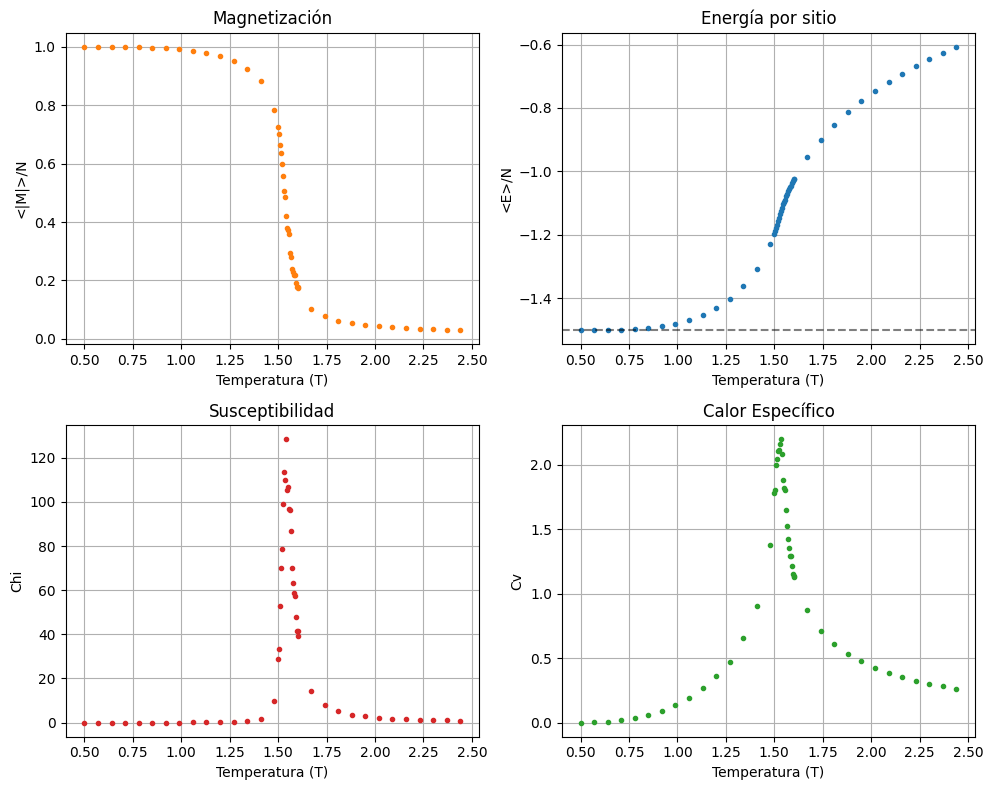

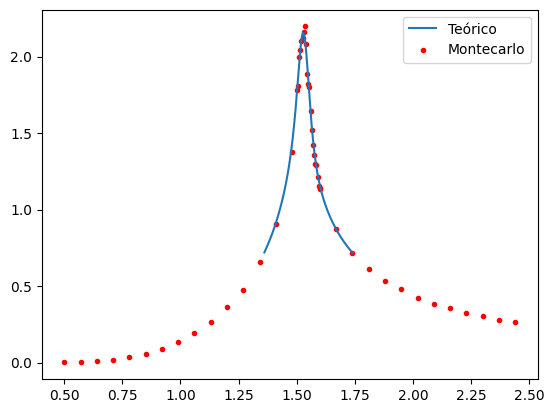

1.5278124742587489


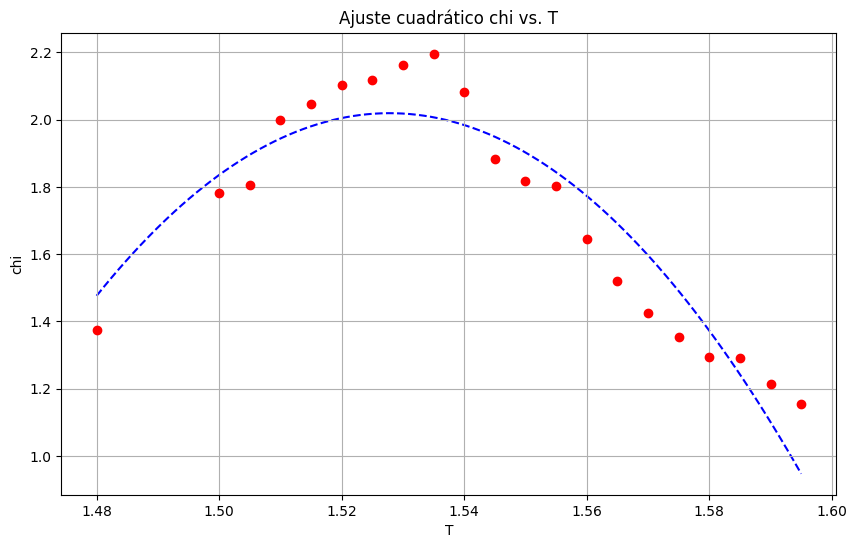

T_max = 1.5278124742587489 +/- 0.0024325437320693558


In [ ]:
# Hexagonal N = 44

df_hex_44 = pd.read_csv('/content/ising_hex_L44.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_hex_44['Temperatura'], df_hex_44['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_hex_44['Temperatura'], df_hex_44['Energia_por_sitio'], '.', color='tab:blue')
plt.axhline(-1.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_hex_44['Temperatura'], df_hex_44['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_hex_44['Temperatura'], df_hex_44['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

df_hex_teo_44 = pd.read_csv('/content/c_44x44.csv')

plt.plot(df_hex_teo_44.iloc[:, 0], df_hex_teo_44.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_hex_44['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 14
m = 35
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_hex_44['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)

plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_hex_44['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_44 = T_max
err_Tc_44 = sigma_Tmax

Tc_44 = T_max
err_Tc_44 = sigma_Tmax

print("T_max =", Tc_44, "+/-", err_Tc_44)

### L = 56

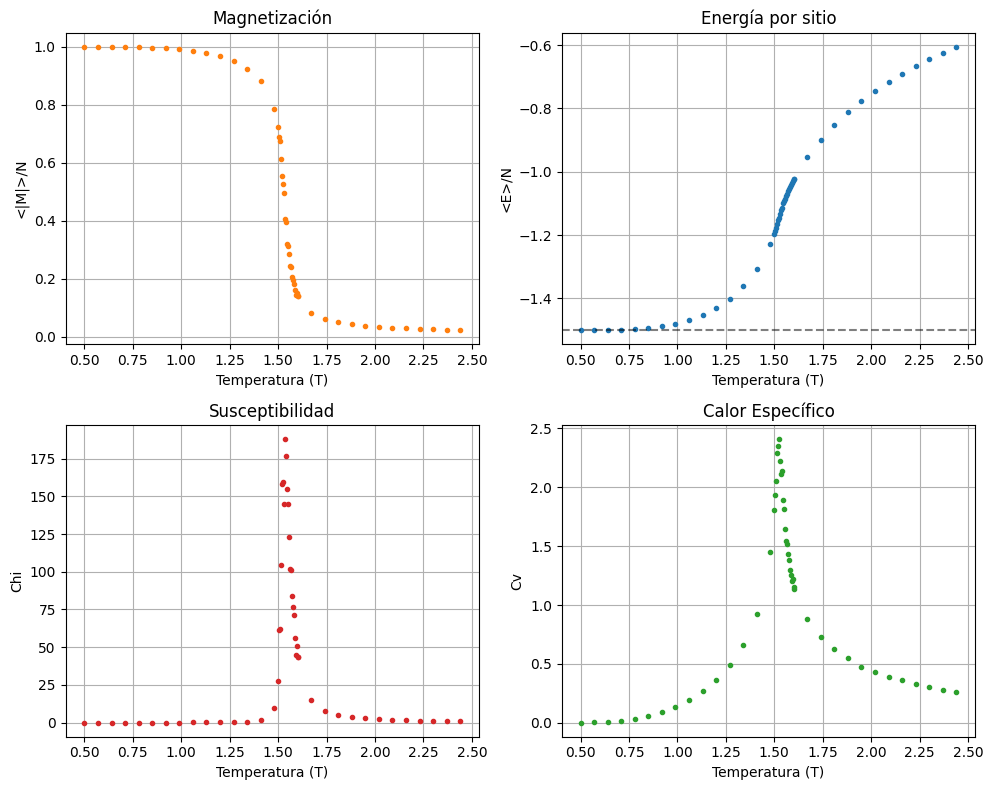

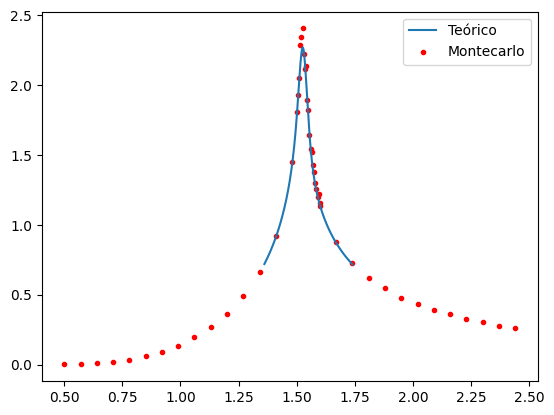

1.5236017731356999


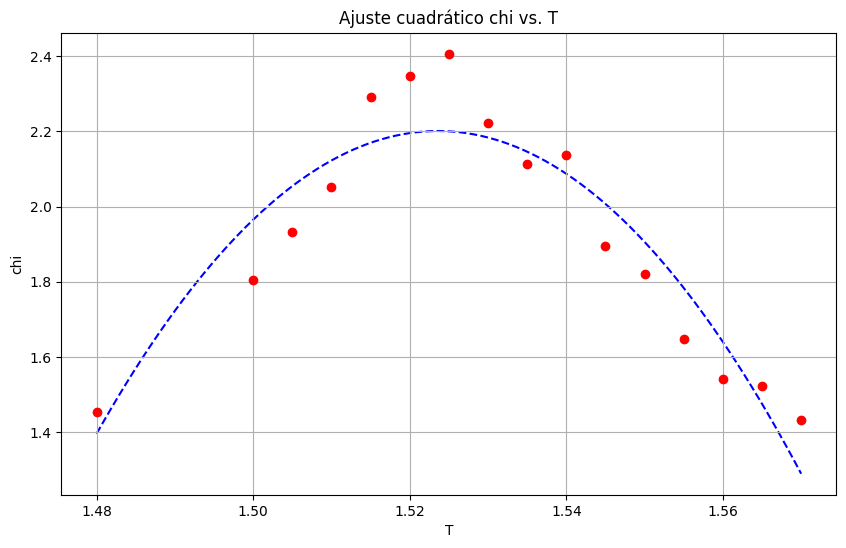

T_max = 1.5236017731356999 +/- 0.0015834916676953329


In [ ]:
# Hexagonal N = 56

df_hex_56 = pd.read_csv('/content/ising_hex_L56.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_hex_56['Temperatura'], df_hex_56['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_hex_56['Temperatura'], df_hex_56['Energia_por_sitio'], '.', color='tab:blue')
plt.axhline(-1.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_hex_56['Temperatura'], df_hex_56['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_hex_56['Temperatura'], df_hex_56['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

df_hex_teo_56 = pd.read_csv('/content/c_56x56.csv')

plt.plot(df_hex_teo_56.iloc[:, 0], df_hex_teo_56.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_hex_56['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 14
m = 30
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_hex_56['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)

plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_hex_56['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_56 = T_max
err_Tc_56 = sigma_Tmax

Tc_56 = T_max
err_Tc_56 = sigma_Tmax

print("T_max =", Tc_56, "+/-", err_Tc_56)

### L = 72

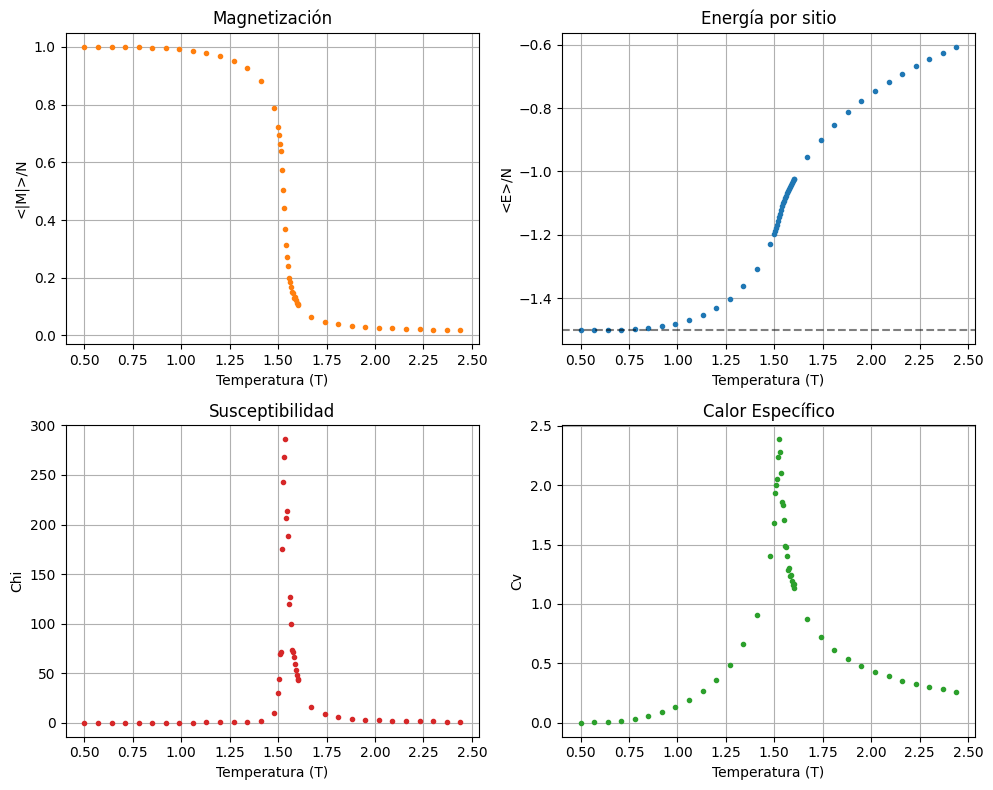

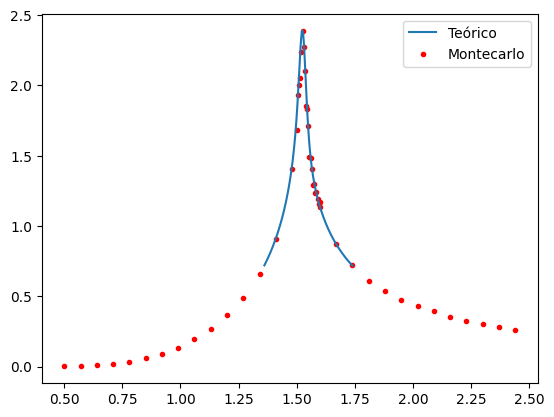

1.5227833381802176


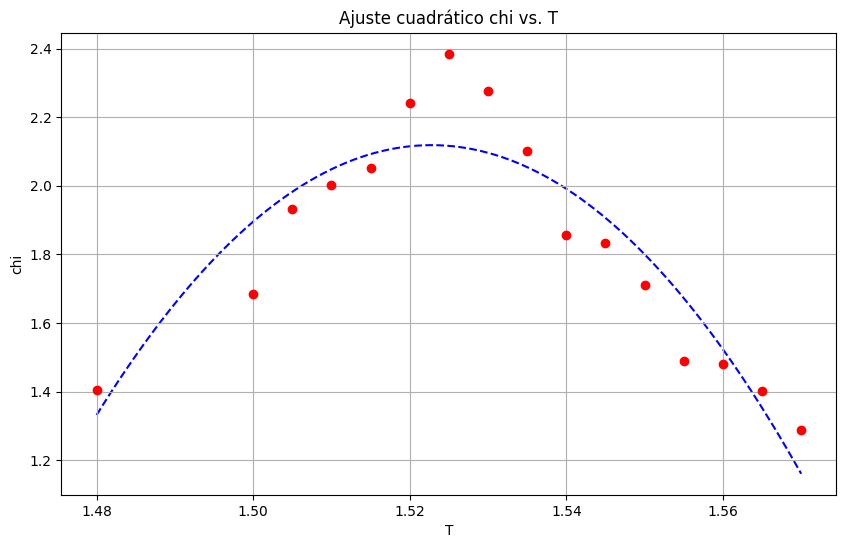

T_max = 1.5227833381802176 +/- 0.0018146001464989408


In [ ]:
# Hexagonal N = 72

df_hex_72 = pd.read_csv('/content/ising_hex_L72.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_hex_72['Temperatura'], df_hex_72['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_hex_72['Temperatura'], df_hex_72['Energia_por_sitio'], '.', color='tab:blue')
plt.axhline(-1.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_hex_72['Temperatura'], df_hex_72['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_hex_72['Temperatura'], df_hex_72['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

temperaturas = np.concatenate((
    np.arange(0.5, 1.5, 0.07),
    np.arange(1.5, 1.6, 0.005),
    np.arange(1.6, 2.5, 0.07)
))

df_hex_teo_72 = pd.read_csv('/content/c_72x72.csv')

plt.plot(df_hex_teo_72.iloc[:, 0], df_hex_teo_72.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_hex_72['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 14
m = 30
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_hex_72['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)

plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_hex_72['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error


Tc_72 = T_max
err_Tc_72 = sigma_Tmax

print("T_max =", Tc_72, "+/-", err_Tc_72)



###L=88

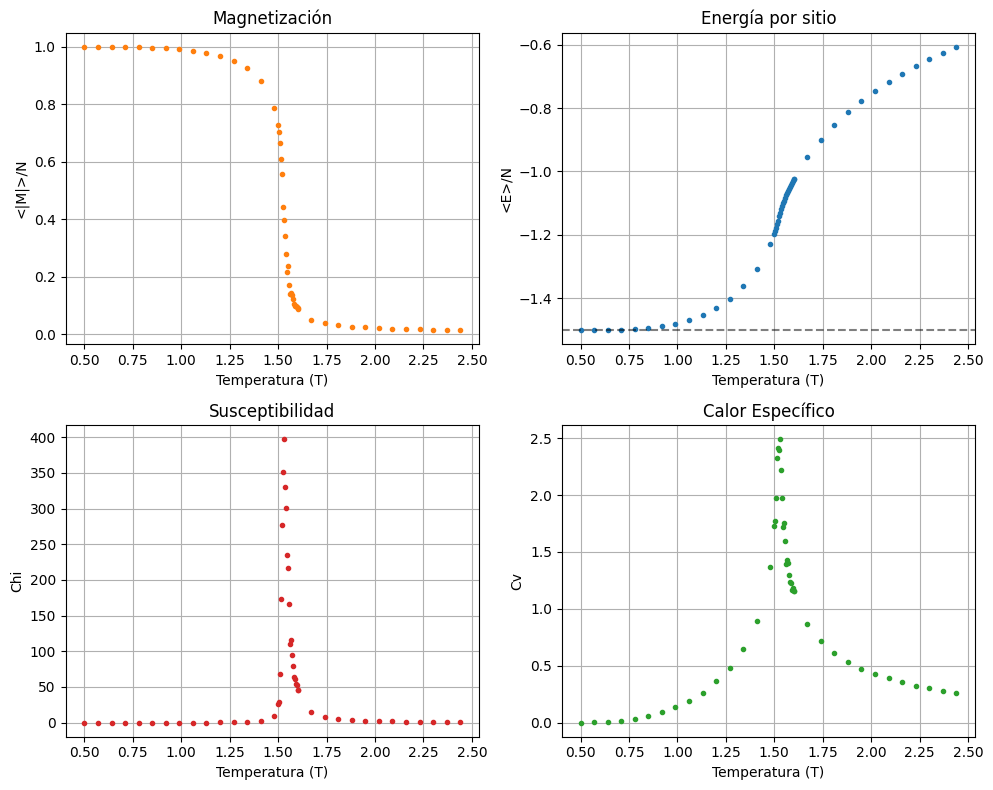

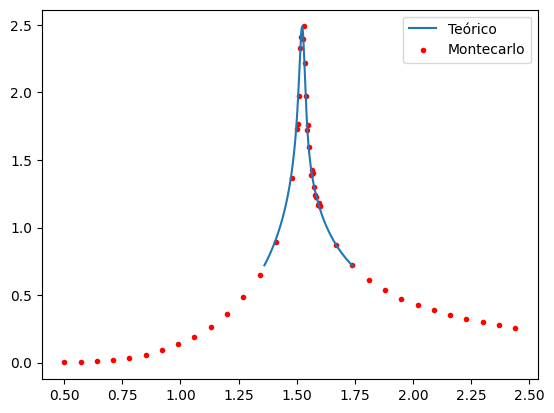

1.5238309974921158


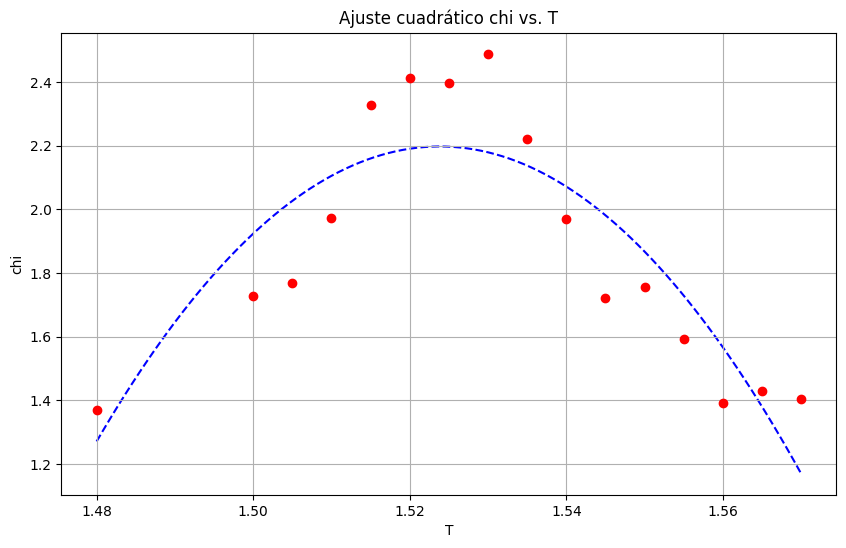

T_max = 1.5238309974921158 +/- 0.002263092817201785


In [ ]:
# Hexagonal N = 88

df_hex_88 = pd.read_csv('/content/ising_hex_L88.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_hex_88['Temperatura'], df_hex_88['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_hex_88['Temperatura'], df_hex_88['Energia_por_sitio'], '.', color='tab:blue')
plt.axhline(-1.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_hex_88['Temperatura'], df_hex_88['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_hex_88['Temperatura'], df_hex_88['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

df_hex_teo_88 = pd.read_csv('/content/c_88x88.csv')

plt.plot(df_hex_teo_88.iloc[:, 0], df_hex_teo_88.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_hex_88['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 14
m = 30
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_hex_88['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)

plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_hex_88['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_88 = T_max
err_Tc_88 = sigma_Tmax

print("T_max =", Tc_88, "+/-", err_Tc_88)

###L=100

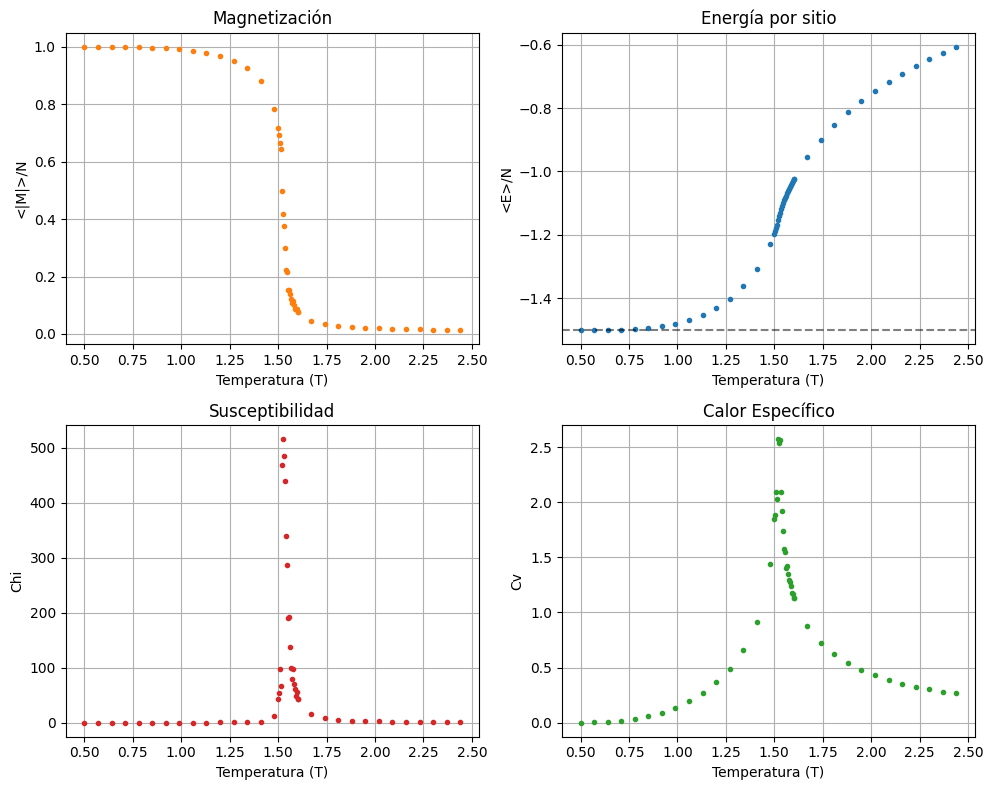

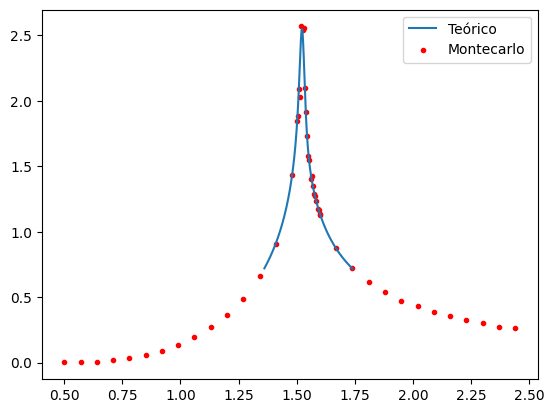

1.5218658860565848


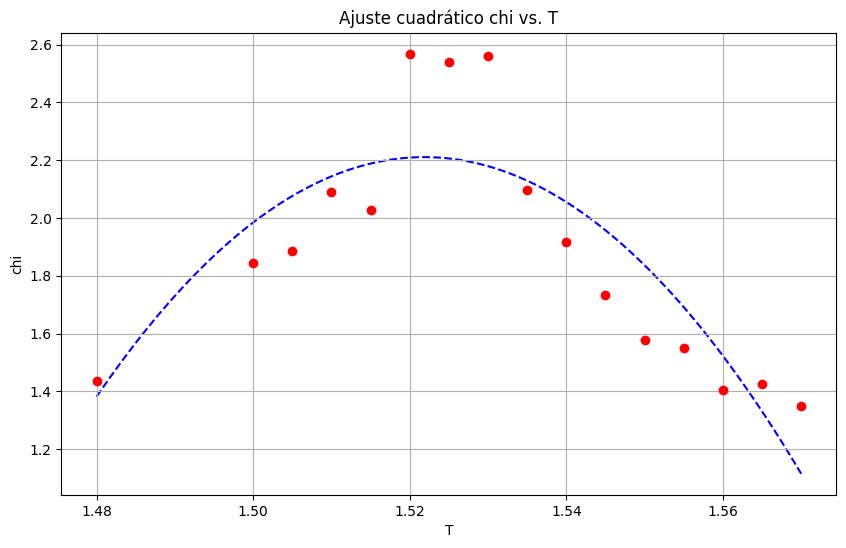

T_max = 1.5218658860565848 +/- 0.002761130845563078


In [ ]:
# Hexagonal N = 100

df_hex_100 = pd.read_csv('/content/ising_hex_L100.csv')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(df_hex_100['Temperatura'], df_hex_100['Magnetizacion_por_sitio'], '.', color='tab:orange')
plt.xlabel('Temperatura (T)')
plt.ylabel('<|M|>/N')
plt.title('Magnetización')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df_hex_100['Temperatura'], df_hex_100['Energia_por_sitio'], '.', color='tab:blue')
plt.axhline(-1.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Temperatura (T)')
plt.ylabel('<E>/N')
plt.title('Energía por sitio')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df_hex_100['Temperatura'], df_hex_100['Susceptibilidad'], '.', color='tab:red')
plt.xlabel('Temperatura (T)')
plt.ylabel('Chi')
plt.title('Susceptibilidad')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df_hex_100['Temperatura'], df_hex_100['Calor_Especifico'], '.', color='tab:green')
plt.xlabel('Temperatura (T)')
plt.ylabel('Cv')
plt.title('Calor Específico')
plt.grid(True)

plt.tight_layout()
plt.show()

df_hex_teo_100 = pd.read_csv('/content/c_100x100.csv')

plt.plot(df_hex_teo_100.iloc[:, 0], df_hex_teo_100.iloc[:, 1], label = 'Teórico')
plt.scatter(temperaturas, df_hex_100['Calor_Especifico'], marker='.', color="red", label = 'Montecarlo')
plt.legend()
plt.show()

n = 14
m = 30
popt, pcov = curve_fit(cuadratica, temperaturas[n:m], df_hex_100['Calor_Especifico'][n:m])
a_opt, b_opt, c_opt = popt

T_ajuste = np.linspace(temperaturas[n:m].min(), temperaturas[n:m].max(), 100)
chi_ajuste = cuadratica(T_ajuste, *popt)
T_max = -b_opt / (2 * a_opt)
print(T_max)

plt.figure(figsize=(10, 6))
plt.scatter(temperaturas[n:m], df_hex_100['Calor_Especifico'][n:m], color='red', zorder=2)
plt.plot(T_ajuste, chi_ajuste, color='blue', linestyle='--', zorder=1)
plt.title('Ajuste cuadrático chi vs. T')
plt.xlabel('T')
plt.ylabel('chi')
plt.grid(True)
plt.show()

sigma_a2 = pcov[0,0]
sigma_b2 = pcov[1,1]
sigma_ab = pcov[0,1]

rel_error = np.sqrt(sigma_a2/a_opt**2 + sigma_b2/b_opt**2 - 2*sigma_ab/(a_opt*b_opt))
sigma_Tmax = abs(T_max) * rel_error

Tc_100 = T_max
err_Tc_100 = sigma_Tmax

print("T_max =", Tc_100, "+/-", err_Tc_100)

##Ajuste lineal de temperatura crítica

| N  | Tc     | Error     |
|----|-------|-------|
| 10| 1.5542 | 0.0019 |
| 12| 1.5484 | 0.0014 |
| 15| 1.5441 | 0.0011|
| 16| 1.5420| 0.0008 |
| 20|  1.5374 | 0.0007 |
| 22| 1.5385  | 0.0009 |
| 34| 1.5316  | 0.0017 |
| 44|  1.5278 | 0.0024   |
|56 | 1.5242 | 0.0041|
|72 | 1.5229 | 0.0052 |
|88 | 1.5248 | 0.0052   |
| 100 |  1.5211 |0.0070          |

En este caso, tomamos L = N + 1.

<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1808912983.py:15: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(inv_L, Tc_ajuste, color='blue', linestyle='--', label = f'$T_c = ({b_opt_hex:.6f} \pm {error_b_hex:.6f})$')


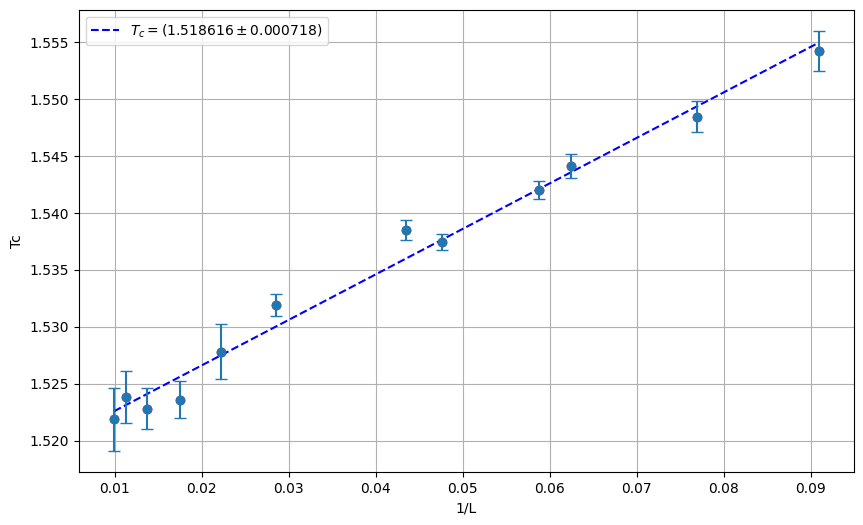

[0.39939761 1.51861579] [[ 2.23344085e-04 -8.99753087e-06]
 [-8.99753087e-06  5.16220546e-07]]


In [ ]:
inv_L = np.array([1/101, 1/89, 1/73, 1/57, 1/45, 1/35, 1/23, 1/21, 1/17, 1/16, 1/13, 1/11]) # 1/L, L = N + 1
Tc = np.array([Tc_100, Tc_88, Tc_72, Tc_56, Tc_44, Tc_34, Tc_22, Tc_20, Tc_16, Tc_15, Tc_12, Tc_10])
errores_Tc = np.array([err_Tc_100, err_Tc_88, err_Tc_72, err_Tc_56, err_Tc_44, err_Tc_34, err_Tc_22, err_Tc_20, err_Tc_16, err_Tc_15, err_Tc_12, err_Tc_10])

popt, pcov = curve_fit(lineal, inv_L, Tc)
m_opt_hex, b_opt_hex = popt

#inv_L_ajuste = np.linspace(temperaturas[30:55].min(), temperaturas[30:55].max(), 100)
Tc_ajuste = lineal(inv_L, *popt)

error_b_hex = np.sqrt(pcov[1, 1])

plt.figure(figsize=(10, 6))
plt.scatter(inv_L, Tc, color='red', zorder=2)
plt.plot(inv_L, Tc_ajuste, color='blue', linestyle='--', label = f'$T_c = ({b_opt_hex:.6f} \pm {error_b_hex:.6f})$')
plt.errorbar(inv_L, Tc, yerr = errores_Tc, fmt='o', capsize=4)
plt.xlabel('1/L')
plt.ylabel('Tc')
plt.grid(True)
plt.legend(loc = 'upper left')

plt.show()
print(popt, pcov)

**Los errores en el cálculo de $T_c$, tanto para la red cuadrada como para la hexagonal, son del orden del error pedido: $10^{-4}$**